### Reason for NaN: invalid / B, IH, Si / out of hva range / don't have core

### Config

In [10]:
import os 
import numpy as np
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors

from tqdm import tqdm
from rdkit import Chem, RDLogger
from multiprocessing import Pool, cpu_count
RDLogger.DisableLog('rdApp.*')
sns.set_style("whitegrid")
os.chdir("/home/80027464/LatentRL/tools/notebook/")

data_dir = "/home/80027464/LatentRL/data/" 
figure_dir = "/home/80027464/LatentRL/figures/"

color_rl = '#2E86AB' 
color_comb = '#A23B72'  
color_rl_docking = '#E07B39'

MIN_LOGP, MAX_LOGP = 2.56, 5.03
MIN_MW, MAX_MW = 473, 676
MIN_HEAVY_ATOMS, MAX_HEAVY_ATOMS = 34, 48

def read_input(path):
    with open(path, "r") as f:
        return [l.strip() for l in f.readlines()]

### Data Loading

In [2]:
all_docking = pd.read_csv(data_dir + "docking/all_canonicalized.csv")
smiles_to_affinity = all_docking.set_index('SMILES')['lowest_mode1_affinity']

all_comb = pd.read_csv(data_dir + "combinatorial/all_canonicalized.csv") 
all_comb = all_comb.drop_duplicates(subset="SMILES", keep='first').reset_index(drop=True)
all_comb = all_comb[~all_comb['SMILES'].str.contains('IH')].copy()
all_comb.rename(columns={'logP': 'LogP', 'num_heavy_atoms': 'NumHeavyAtoms'}, inplace=True)

all_comb_hva = all_comb[all_comb['NumHeavyAtoms'].between(MIN_HEAVY_ATOMS, MAX_HEAVY_ATOMS)].copy()
all_comb_filtered = all_comb[
    (all_comb['NumHeavyAtoms'].between(MIN_HEAVY_ATOMS, MAX_HEAVY_ATOMS)) &
    (all_comb['MW'].between(MIN_MW, MAX_MW)) &
    (all_comb['LogP'].between(MIN_LOGP, MAX_LOGP))
].copy()

rl1 = pd.read_csv(data_dir + "latent_rl/output/rl1/results_canonicalized.csv")
rl2 = pd.read_csv(data_dir + "latent_rl/output/rl2/results_canonicalized.csv")
rl3 = pd.read_csv(data_dir + "latent_rl/output/rl3/results_canonicalized.csv")
all_rl = pd.concat([rl1, rl2, rl3], ignore_index=True).drop_duplicates(subset="SMILES", keep='first').reset_index(drop=True)
all_rl = all_rl[~all_rl['SMILES'].str.contains('IH')].copy()
all_rl = all_rl.dropna()

all_rl_hassubstructure = all_rl[all_rl['HasSubstructure'] == True].copy()
all_rl_hva = all_rl_hassubstructure[all_rl_hassubstructure['NumHeavyAtoms'].between(MIN_HEAVY_ATOMS, MAX_HEAVY_ATOMS)].copy()

all_rl_filtered = all_rl[
    (all_rl['HasSubstructure'] == True) &
    (all_rl['NumHeavyAtoms'].between(MIN_HEAVY_ATOMS, MAX_HEAVY_ATOMS)) &
    (all_rl['MW'].between(MIN_MW, MAX_MW)) &
    (all_rl['LogP'].between(MIN_LOGP, MAX_LOGP))
].copy()

rl_docking1 = pd.read_csv(data_dir + "latent_rl/output/rl_docking1/results_canonicalized.csv")
rl_docking2 = pd.read_csv(data_dir + "latent_rl/output/rl_docking2/results_canonicalized.csv")
rl_docking3 = pd.read_csv(data_dir + "latent_rl/output/rl_docking3/results_canonicalized.csv")
all_rl_docking = pd.concat([rl_docking1, rl_docking2, rl_docking3], ignore_index=True).drop_duplicates(subset="SMILES", keep='first').reset_index(drop=True)
all_rl_docking = all_rl_docking[~all_rl_docking['SMILES'].str.contains('IH')].copy()
all_rl_docking = all_rl_docking.dropna()

all_rl_docking_hassubstructure = all_rl_docking[all_rl_docking['HasSubstructure'] == True].copy()
all_rl_docking_hva = all_rl_docking_hassubstructure[all_rl_docking_hassubstructure['NumHeavyAtoms'].between(MIN_HEAVY_ATOMS, MAX_HEAVY_ATOMS)].copy()

all_rl_docking_filtered = all_rl_docking[
    (all_rl_docking['HasSubstructure'] == True) &
    (all_rl_docking['NumHeavyAtoms'].between(MIN_HEAVY_ATOMS, MAX_HEAVY_ATOMS)) &
    (all_rl_docking['MW'].between(MIN_MW, MAX_MW)) &
    (all_rl_docking['LogP'].between(MIN_LOGP, MAX_LOGP))
].copy()


pareto_rl_1k_nodock = pd.read_csv(data_dir + "pareto/pareto_rl_1k_nodock.csv")
pareto_comb_1k_nodock = pd.read_csv(data_dir + "pareto/pareto_comb_1k_nodock.csv")
pareto_comb_1stfront_docking = pd.read_csv(data_dir + "pareto/pareto_comb_1stfront_docking.csv")
pareto_rl_1stfront_docking = pd.read_csv(data_dir + "pareto/pareto_rl_1stfront_docking.csv")
pareto_rl_docking_1stfront_docking = pd.read_csv(data_dir + "pareto/pareto_rl_docking_1stfront_docking.csv")

all_comb['lowest_mode1_affinity'] = all_comb['SMILES'].map(smiles_to_affinity)
all_comb_filtered['lowest_mode1_affinity'] = all_comb_filtered['SMILES'].map(smiles_to_affinity)
all_comb_hva['lowest_mode1_affinity'] = all_comb_hva['SMILES'].map(smiles_to_affinity)
all_rl['lowest_mode1_affinity'] = all_rl['SMILES'].map(smiles_to_affinity)
all_rl_hassubstructure['lowest_mode1_affinity'] = all_rl_hassubstructure['SMILES'].map(smiles_to_affinity)
all_rl_hva['lowest_mode1_affinity'] = all_rl_hva['SMILES'].map(smiles_to_affinity)
all_rl_filtered['lowest_mode1_affinity'] = all_rl_filtered['SMILES'].map(smiles_to_affinity)
all_rl_docking['lowest_mode1_affinity'] = all_rl_docking['SMILES'].map(smiles_to_affinity)
all_rl_docking_hassubstructure['lowest_mode1_affinity'] = all_rl_docking_hassubstructure['SMILES'].map(smiles_to_affinity)
all_rl_docking_hva['lowest_mode1_affinity'] = all_rl_docking_hva['SMILES'].map(smiles_to_affinity)
all_rl_docking_filtered['lowest_mode1_affinity'] = all_rl_docking_filtered['SMILES'].map(smiles_to_affinity)
pareto_comb_1k_nodock['lowest_mode1_affinity'] = pareto_comb_1k_nodock['SMILES'].map(smiles_to_affinity)
pareto_rl_1k_nodock['lowest_mode1_affinity'] = pareto_rl_1k_nodock['SMILES'].map(smiles_to_affinity)
pareto_comb_1stfront_docking['lowest_mode1_affinity'] = pareto_comb_1stfront_docking['SMILES'].map(smiles_to_affinity)
pareto_rl_1stfront_docking['lowest_mode1_affinity'] = pareto_rl_1stfront_docking['SMILES'].map(smiles_to_affinity)
pareto_rl_docking_1stfront_docking['lowest_mode1_affinity'] = pareto_rl_docking_1stfront_docking['SMILES'].map(smiles_to_affinity)

all_comb = all_comb.dropna(subset=['lowest_mode1_affinity'])
all_comb_filtered = all_comb_filtered.dropna(subset=['lowest_mode1_affinity'])
all_comb_hva = all_comb_hva.dropna(subset=['lowest_mode1_affinity'])
all_rl = all_rl.dropna(subset=['lowest_mode1_affinity'])
all_rl_hassubstructure = all_rl_hassubstructure.dropna(subset=['lowest_mode1_affinity'])
all_rl_hva = all_rl_hva.dropna(subset=['lowest_mode1_affinity'])
all_rl_filtered = all_rl_filtered.dropna(subset=['lowest_mode1_affinity'])
all_rl_docking = all_rl_docking.dropna(subset=['lowest_mode1_affinity'])
all_rl_docking_hassubstructure = all_rl_docking_hassubstructure.dropna(subset=['lowest_mode1_affinity'])
all_rl_docking_hva = all_rl_docking_hva.dropna(subset=['lowest_mode1_affinity'])
all_rl_docking_filtered = all_rl_docking_filtered.dropna(subset=['lowest_mode1_affinity'])
pareto_comb_1k_nodock = pareto_comb_1k_nodock.dropna(subset=['lowest_mode1_affinity'])
pareto_rl_1k_nodock = pareto_rl_1k_nodock.dropna(subset=['lowest_mode1_affinity'])
pareto_comb_1stfront_docking = pareto_comb_1stfront_docking.dropna(subset=['lowest_mode1_affinity'])
pareto_rl_1stfront_docking = pareto_rl_1stfront_docking.dropna(subset=['lowest_mode1_affinity'])
pareto_rl_docking_1stfront_docking = pareto_rl_docking_1stfront_docking.dropna(subset=['lowest_mode1_affinity'])

print(f"all_comb: {len(all_comb):,}")
print(f"all_comb_filtered: {len(all_comb_filtered):,}")
print(f"all_comb_hva: {len(all_comb_hva):,}\n")

print(f"all_rl: {len(all_rl):,}")
print(f"all_rl_filtered: {len(all_rl_filtered):,}")
print(f"all_rl_hassubstructure: {len(all_rl_hassubstructure):,}")
print(f"all_rl_hva: {len(all_rl_hva):,}\n")

print(f"all_rl_docking: {len(all_rl_docking):,}")
print(f"all_rl_docking_filtered: {len(all_rl_docking_filtered):,}")
print(f"all_rl_docking_hassubstructure: {len(all_rl_docking_hassubstructure):,}")
print(f"all_rl_docking_hva: {len(all_rl_docking_hva):,}\n")

print(f"pareto_comb_1k_nodock: {len(pareto_comb_1k_nodock):,}")
print(f"pareto_rl_1k_nodock: {len(pareto_rl_1k_nodock):,}")
print(f"pareto_comb_1stfront_docking: {len(pareto_comb_1stfront_docking):,}")
print(f"pareto_rl_1stfront_docking: {len(pareto_rl_1stfront_docking):,}")
print(f"pareto_rl_docking_1stfront_docking: {len(pareto_rl_docking_1stfront_docking):,}")

all_comb: 184,401
all_comb_filtered: 108,695
all_comb_hva: 184,142

all_rl: 125,167
all_rl_filtered: 69,161
all_rl_hassubstructure: 125,167
all_rl_hva: 124,786

all_rl_docking: 118,792
all_rl_docking_filtered: 58,527
all_rl_docking_hassubstructure: 118,792
all_rl_docking_hva: 118,792

pareto_comb_1k_nodock: 1,000
pareto_rl_1k_nodock: 1,000
pareto_comb_1stfront_docking: 320
pareto_rl_1stfront_docking: 391
pareto_rl_docking_1stfront_docking: 346


### Figure 2

In [5]:
import sys 
import rdkit 
from rdkit import Chem
sys.path.append('../..') 
from utils import get_logp, get_mw, get_num_heavy_atoms, get_sa
from multiprocessing import Pool, cpu_count
import numpy as np
from tqdm import tqdm

with open('../../data/raw/zinc22/zinc22_heavy_atoms_30to49_mw750_canonical.txt', 'r') as f: 
    zinc_smiles = [line.strip() for line in f.readlines()]

MBC = 'c1c(c(c2c(c1)c(c(c(=O)o2)NC(=O)c1cc(c(cc1)O)CC=C(C)C)O)C)O[C@H]1[C@@H]([C@@H]([C@H](C(O1)(C)C)OC)OC(=O)c1[nH]c(cc1)C)O'
MBC_core = 'c1c(c(c2c(c1)c(cc(=O)o2)O)C)O[C@H]1[C@@H]([C@@H]([C@H](C(O1)(C)C)OC)OC(=O)c1[nH]c(cc1)C)O'

import matplotlib.pyplot as plt

# Function to compute properties for a single SMILES
def compute_properties(smiles):
    try:
        logp = get_logp(smiles)
        mw = get_mw(smiles)
        num_heavy = get_num_heavy_atoms(smiles)
        sa = get_sa(smiles)
        return (logp, mw, num_heavy, sa)
    except:
        return (None, None, None, None)

# Use all available CPUs
n_cpus = cpu_count()
print(f"Using {n_cpus} CPUs for parallel computation...")

# Compute properties in parallel with progress bar
with Pool(n_cpus) as pool:
    results = list(tqdm(pool.imap(compute_properties, zinc_smiles), total=len(zinc_smiles), desc="Computing properties"))

# Separate results into individual property lists
zinc_logp = [r[0] for r in results if r[0] is not None]
zinc_mw = [r[1] for r in results if r[1] is not None]
zinc_heavy = [r[2] for r in results if r[2] is not None]
zinc_sa = [r[3] for r in results if r[3] is not None]

print(f"Computed properties for {len(zinc_logp)} molecules")

# Compute MBC properties
mbc_logp = get_logp(MBC)
mbc_mw = get_mw(MBC)
mbc_heavy = get_num_heavy_atoms(MBC)
mbc_sa = get_sa(MBC)

mbc_core_logp = get_logp(MBC_core)
mbc_core_mw = get_mw(MBC_core)
mbc_core_heavy = get_num_heavy_atoms(MBC_core)
mbc_core_sa = get_sa(MBC_core)

Using 64 CPUs for parallel computation...


Computing properties: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 6974245/6974245 [04:15<00:00, 27261.77it/s]


Computed properties for 6974245 molecules


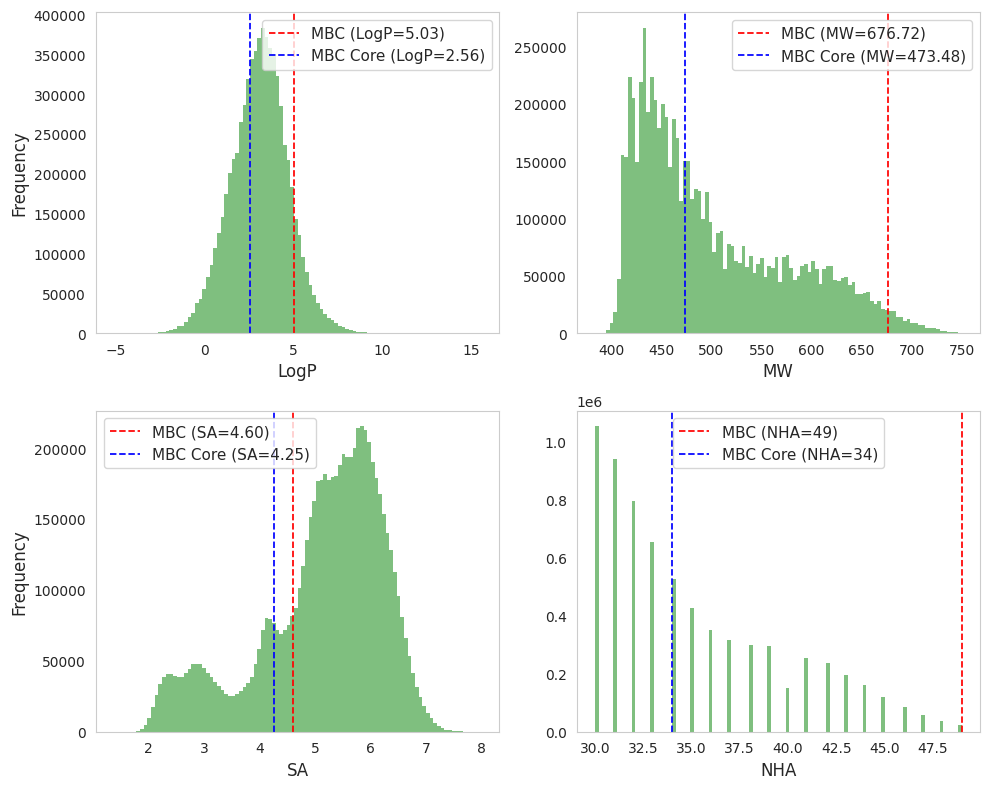

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

# Plot LogP distribution
axes[0, 0].hist(zinc_logp, bins=100, alpha=0.5, color='green', linewidth=0.5, edgecolor='none')
axes[0, 0].axvline(mbc_logp, color='red', linestyle='--', linewidth=1.25, label=f'MBC (LogP={mbc_logp:.2f})')
axes[0, 0].axvline(mbc_core_logp, color='blue', linestyle='--', linewidth=1.25, label=f'MBC Core (LogP={mbc_core_logp:.2f})')
axes[0, 0].set_xlabel('LogP', fontsize=12)
axes[0, 0].set_ylabel('Frequency', fontsize=12)
axes[0, 0].legend(fontsize=11)
axes[0, 0].grid(alpha=0.0)

# Plot MW distribution
axes[0, 1].hist(zinc_mw, bins=100, alpha=0.5, color='green', linewidth=0.5, edgecolor='none')
axes[0, 1].axvline(mbc_mw, color='red', linestyle='--', linewidth=1.25, label=f'MBC (MW={mbc_mw:.2f})')
axes[0, 1].axvline(mbc_core_mw, color='blue', linestyle='--', linewidth=1.25, label=f'MBC Core (MW={mbc_core_mw:.2f})')
axes[0, 1].set_xlabel('MW', fontsize=12)
axes[0, 1].legend(fontsize=11)
axes[0, 1].grid(alpha=0.0)

# Plot Number of Heavy Atoms distribution
axes[1, 1].hist(zinc_heavy, bins=100, alpha=0.5, color='green', linewidth=0.5, edgecolor='none')
axes[1, 1].axvline(mbc_heavy, color='red', linestyle='--', linewidth=1.25, label=f'MBC (NHA={mbc_heavy})')
axes[1, 1].axvline(mbc_core_heavy, color='blue', linestyle='--', linewidth=1.25, label=f'MBC Core (NHA={mbc_core_heavy})')
axes[1, 1].set_xlabel('NHA', fontsize=12)
axes[1, 1].legend(fontsize=11)
axes[1, 1].grid(alpha=0.0)

# Plot SA distribution
axes[1, 0].hist(zinc_sa, bins=100, alpha=0.5, color='green', linewidth=0.5, edgecolor='none')
axes[1, 0].axvline(mbc_sa, color='red', linestyle='--', linewidth=1.25, label=f'MBC (SA={mbc_sa:.2f})')
axes[1, 0].axvline(mbc_core_sa, color='blue', linestyle='--', linewidth=1.25, label=f'MBC Core (SA={mbc_core_sa:.2f})')
axes[1, 0].set_xlabel('SA', fontsize=12)
axes[1, 0].set_ylabel('Frequency', fontsize=12)
axes[1, 0].legend(fontsize=11)
axes[1, 0].grid(alpha=0.0)

plt.tight_layout()
plt.savefig('../../figures/figure2_zinc_properties_dist.pdf', dpi=600, bbox_inches='tight', format='pdf')
plt.show()

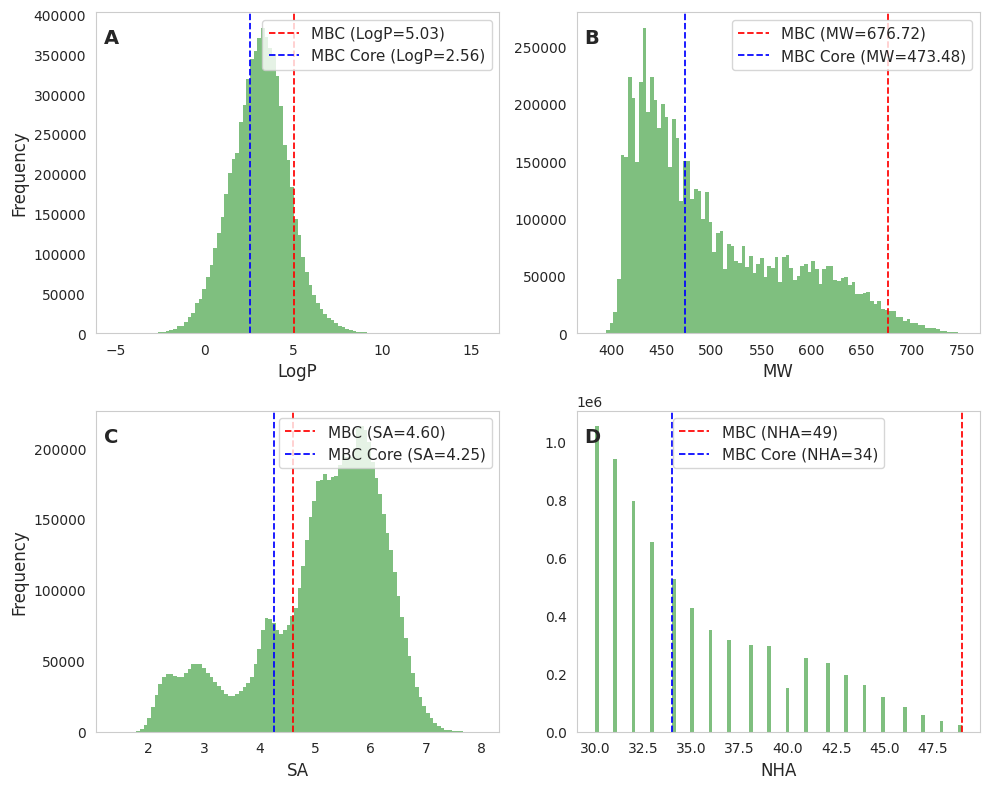

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

# Plot LogP distribution
axes[0, 0].hist(zinc_logp, bins=100, alpha=0.5, color='green', linewidth=0.5, edgecolor='none')
axes[0, 0].axvline(mbc_logp, color='red', linestyle='--', linewidth=1.25, label=f'MBC (LogP={mbc_logp:.2f})')
axes[0, 0].axvline(mbc_core_logp, color='blue', linestyle='--', linewidth=1.25, label=f'MBC Core (LogP={mbc_core_logp:.2f})')
axes[0, 0].set_xlabel('LogP', fontsize=12)
axes[0, 0].set_ylabel('Frequency', fontsize=12)
axes[0, 0].legend(fontsize=11)
axes[0, 0].grid(alpha=0.0)
axes[0, 0].text(0.02, 0.95, 'A', transform=axes[0, 0].transAxes,
                fontsize=14, fontweight='bold', va='top', ha='left')

# Plot MW distribution
axes[0, 1].hist(zinc_mw, bins=100, alpha=0.5, color='green', linewidth=0.5, edgecolor='none')
axes[0, 1].axvline(mbc_mw, color='red', linestyle='--', linewidth=1.25, label=f'MBC (MW={mbc_mw:.2f})')
axes[0, 1].axvline(mbc_core_mw, color='blue', linestyle='--', linewidth=1.25, label=f'MBC Core (MW={mbc_core_mw:.2f})')
axes[0, 1].set_xlabel('MW', fontsize=12)
axes[0, 1].legend(fontsize=11)
axes[0, 1].grid(alpha=0.0)
axes[0, 1].text(0.02, 0.95, 'B', transform=axes[0, 1].transAxes,
                fontsize=14, fontweight='bold', va='top', ha='left')

# Plot SA distribution
axes[1, 0].hist(zinc_sa, bins=100, alpha=0.5, color='green', linewidth=0.5, edgecolor='none')
axes[1, 0].axvline(mbc_sa, color='red', linestyle='--', linewidth=1.25, label=f'MBC (SA={mbc_sa:.2f})')
axes[1, 0].axvline(mbc_core_sa, color='blue', linestyle='--', linewidth=1.25, label=f'MBC Core (SA={mbc_core_sa:.2f})')
axes[1, 0].set_xlabel('SA', fontsize=12)
axes[1, 0].set_ylabel('Frequency', fontsize=12)
axes[1, 0].legend(fontsize=11, loc='upper right')
axes[1, 0].grid(alpha=0.0)
axes[1, 0].text(0.02, 0.95, 'C', transform=axes[1, 0].transAxes,
                fontsize=14, fontweight='bold', va='top', ha='left')

# Plot Number of Heavy Atoms distribution
axes[1, 1].hist(zinc_heavy, bins=100, alpha=0.5, color='green', linewidth=0.5, edgecolor='none')
axes[1, 1].axvline(mbc_heavy, color='red', linestyle='--', linewidth=1.25, label=f'MBC (NHA={mbc_heavy})')
axes[1, 1].axvline(mbc_core_heavy, color='blue', linestyle='--', linewidth=1.25, label=f'MBC Core (NHA={mbc_core_heavy})')
axes[1, 1].set_xlabel('NHA', fontsize=12)
axes[1, 1].legend(fontsize=11)
axes[1, 1].grid(alpha=0.0)
axes[1, 1].text(0.02, 0.95, 'D', transform=axes[1, 1].transAxes,
                fontsize=14, fontweight='bold', va='top', ha='left')

plt.tight_layout()
plt.savefig('../../figures/figure2_zinc_properties_dist_labeled.pdf', dpi=600, bbox_inches='tight', format='pdf')
plt.show()

### Figure 3

In [11]:
import os 
import pandas as pd 
from rdkit import Chem
from tqdm import tqdm
import numpy as np
from rdkit import Chem, RDLogger
from multiprocessing import Pool, cpu_count
RDLogger.DisableLog('rdApp.*')

# Define elegant colors
color_rl = '#2E86AB'  # Blue
color_comb = '#A23B72'  # Purple

with open('/home/80027464/LatentRL/data/combinatorial/combinatorial_alkyl_halide_canonical.txt', 'r') as f: 
    alkyl_halide_comb = [line.strip() for line in f.readlines()]

with open('/home/80027464/LatentRL/data/combinatorial/combinatorial_primary_amine_canonical.txt', 'r') as f: 
    primary_amine_comb = [line.strip() for line in f.readlines()]

rl_folders = os.listdir('../../data/latent_rl/output/MBC')
rl_folders = [folder for folder in rl_folders if not folder.endswith('_2') and not folder.endswith('_3')]
rl_folders.remove('archive'); rl_folders.remove('first_experiment_feb11')

import matplotlib.pyplot as plt

all_data = {}
for folder in rl_folders:
    path = f'../../data/latent_rl/output/MBC/{folder}/results.csv'
    if os.path.exists(path):
        df = pd.read_csv(path)
        all_data[folder] = df

# Aggregate by step
step_stats = {}
for folder, df in all_data.items():
    for step, group in df.groupby('Step'):
        if step not in step_stats:
            step_stats[step] = {'total': 0, 'valid': 0, 'smiles': [], 'logp': []}
        step_stats[step]['total'] += len(group)
        valid_mask = group['LogP'].notna()
        step_stats[step]['valid'] += valid_mask.sum()
        step_stats[step]['smiles'].extend(group.loc[valid_mask, 'SMILES'].tolist())
        step_stats[step]['logp'].extend(group.loc[valid_mask, 'LogP'].tolist())

steps = sorted(step_stats.keys())
valid_pct = [100 * step_stats[s]['valid'] / step_stats[s]['total'] for s in steps]
unique_pct = [100 * len(set(step_stats[s]['smiles'])) / step_stats[s]['valid'] 
              if step_stats[s]['valid'] > 0 else 0 for s in steps]
mean_logp = [np.mean(step_stats[s]['logp']) if step_stats[s]['logp'] else np.nan for s in steps]

comb_canonical_set = set(alkyl_halide_comb + primary_amine_comb)

def canonicalize_smiles(smi):
    mol = Chem.MolFromSmiles(smi)
    if mol is not None:
        return Chem.MolToSmiles(mol)
    return None

# Collect all unique SMILES across all steps
print("Collecting all unique SMILES across all steps...")
all_unique_smiles = set()
for s in steps:
    all_unique_smiles.update(step_stats[s]['smiles'])
all_unique_smiles = list(all_unique_smiles)
print(f"Total unique SMILES: {len(all_unique_smiles)}")

# Canonicalize all unique SMILES in parallel
print("Canonicalizing all unique SMILES in parallel...")
with Pool(64) as pool:
    canon_results = list(tqdm(pool.imap(canonicalize_smiles, all_unique_smiles), total=len(all_unique_smiles), desc="Canonicalizing"))

# Build novelty lookup: original smi -> is_novel
novelty_lookup = {}
for smi, canon in zip(all_unique_smiles, canon_results):
    novelty_lookup[smi] = (canon is not None) and (canon not in comb_canonical_set)

# Compute novel % per step using the lookup
novel_pct = []
for s in tqdm(steps, desc="Computing novel %"):
    smiles_list = step_stats[s]['smiles']
    if len(smiles_list) == 0:
        novel_pct.append(np.nan)
    else:
        novel_count = sum(novelty_lookup[smi] for smi in smiles_list)
        novel_pct.append(100 * novel_count / len(smiles_list))

Total unique SMILES: 1438215
Canonicalizing all unique SMILES in parallel...


Computing novel %: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:01<00:00, 945.45it/s]


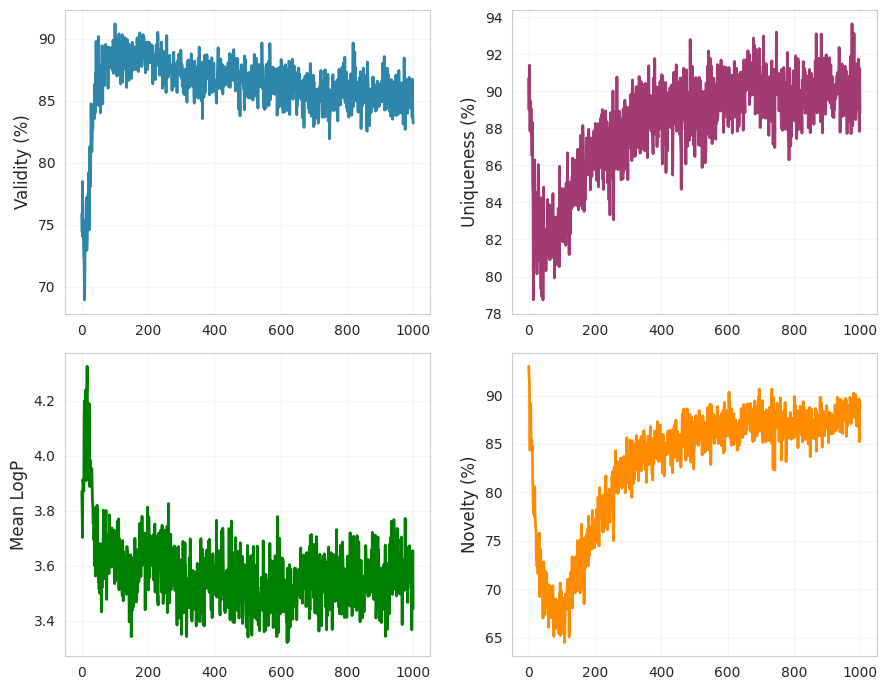

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(9, 7))
axes[0, 0].plot(steps, valid_pct, color=color_rl, linewidth=2)
axes[0, 0].set_ylabel('Validity (%)', fontsize=12)
axes[0, 0].grid(alpha=0.2)

axes[0, 1].plot(steps, unique_pct, color=color_comb, linewidth=2)
axes[0, 1].set_ylabel('Uniqueness (%)', fontsize=12)
axes[0, 1].grid(alpha=0.2)

axes[1, 0].plot(steps, mean_logp, color='green', linewidth=2)
axes[1, 0].set_ylabel('Mean LogP', fontsize=12)
axes[1, 0].grid(alpha=0.2)

axes[1, 1].plot(steps, novel_pct, color='darkorange', linewidth=2)
axes[1, 1].set_ylabel('Novelty (%)', fontsize=12)
axes[1, 1].grid(alpha=0.2)

plt.tight_layout()
plt.savefig('../../figures/figure3_rl_metrics.pdf', dpi=300, bbox_inches='tight', format='pdf')
plt.show()

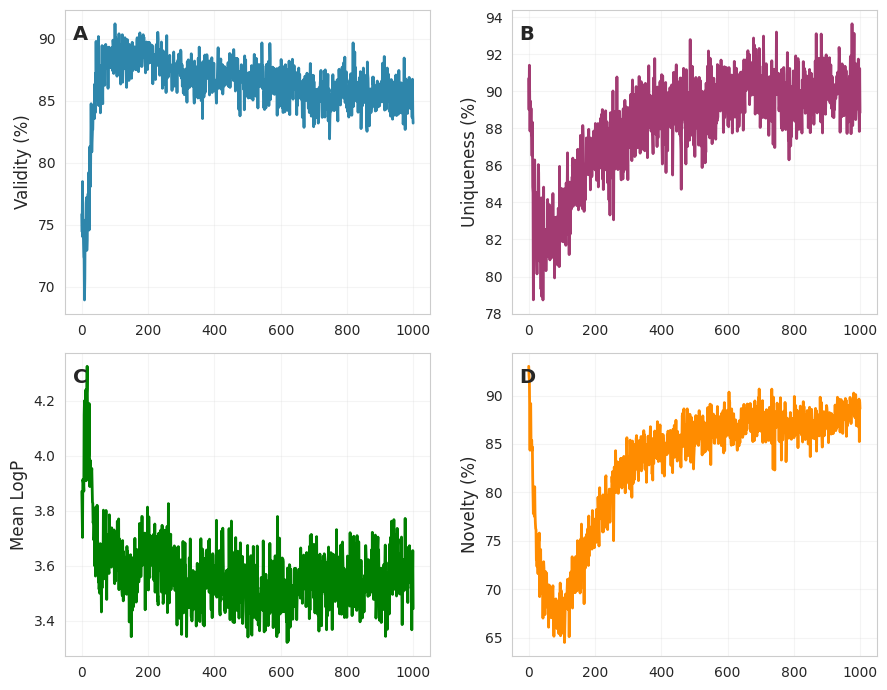

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(9, 7))
axes[0, 0].plot(steps, valid_pct, color=color_rl, linewidth=2)
axes[0, 0].set_ylabel('Validity (%)', fontsize=12)
axes[0, 0].text(0.02, 0.95, 'A', transform=axes[0, 0].transAxes,
                fontsize=14, fontweight='bold', va='top', ha='left')
axes[0, 0].grid(alpha=0.2)

axes[0, 1].plot(steps, unique_pct, color=color_comb, linewidth=2)
axes[0, 1].set_ylabel('Uniqueness (%)', fontsize=12)
axes[0, 1].text(0.02, 0.95, 'B', transform=axes[0, 1].transAxes,
                fontsize=14, fontweight='bold', va='top', ha='left')
axes[0, 1].grid(alpha=0.2)

axes[1, 0].plot(steps, mean_logp, color='green', linewidth=2)
axes[1, 0].set_ylabel('Mean LogP', fontsize=12)
axes[1, 0].text(0.02, 0.95, 'C', transform=axes[1, 0].transAxes,
                fontsize=14, fontweight='bold', va='top', ha='left')
axes[1, 0].grid(alpha=0.2)

axes[1, 1].plot(steps, novel_pct, color='darkorange', linewidth=2)
axes[1, 1].set_ylabel('Novelty (%)', fontsize=12)
axes[1, 1].text(0.02, 0.95, 'D', transform=axes[1, 1].transAxes,
                fontsize=14, fontweight='bold', va='top', ha='left')
axes[1, 1].grid(alpha=0.2)

plt.tight_layout()
plt.savefig('../../figures/figure3_rl_metrics_labeled.pdf', dpi=300, bbox_inches='tight', format='pdf')
plt.show()

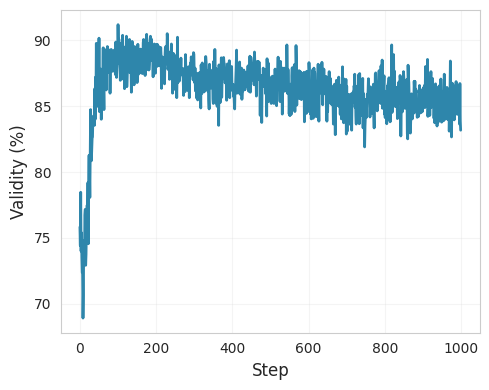

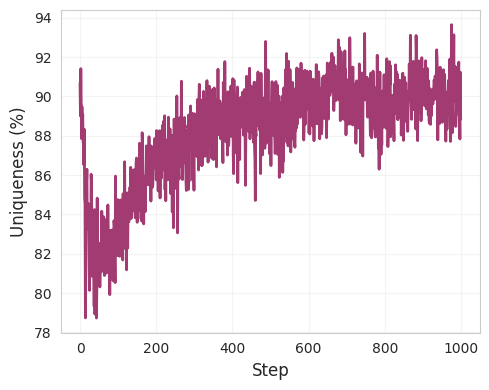

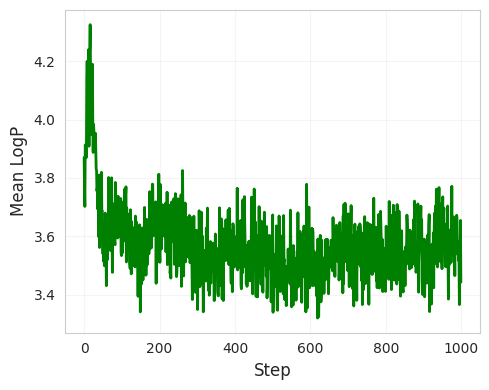

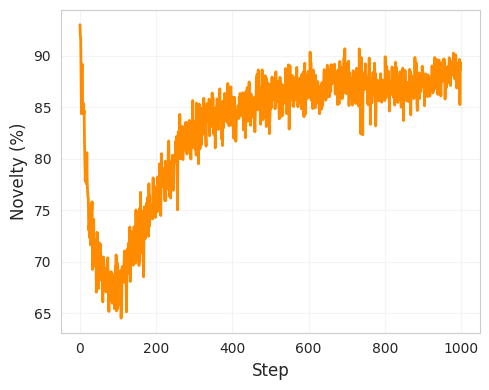

In [16]:
metrics = [
    ("validity", valid_pct, color_rl, "Validity (%)"),
    ("uniqueness", unique_pct, color_comb, "Uniqueness (%)"),
    ("mean_logp", mean_logp, "green", "Mean LogP"),
    ("novelty", novel_pct, "darkorange", "Novelty (%)"),
]

for name, values, color, ylabel in metrics:
    fig, ax = plt.subplots(figsize=(5, 4))
    ax.plot(steps, values, color=color, linewidth=2)
    ax.set_xlabel("Step", fontsize=12)
    ax.set_ylabel(ylabel, fontsize=12)
    ax.grid(alpha=0.2)

    plt.tight_layout()
    plt.savefig(f"../../figures/figure3_{name}.pdf", dpi=300, bbox_inches="tight", format="pdf")
    plt.show()


### Figure 4

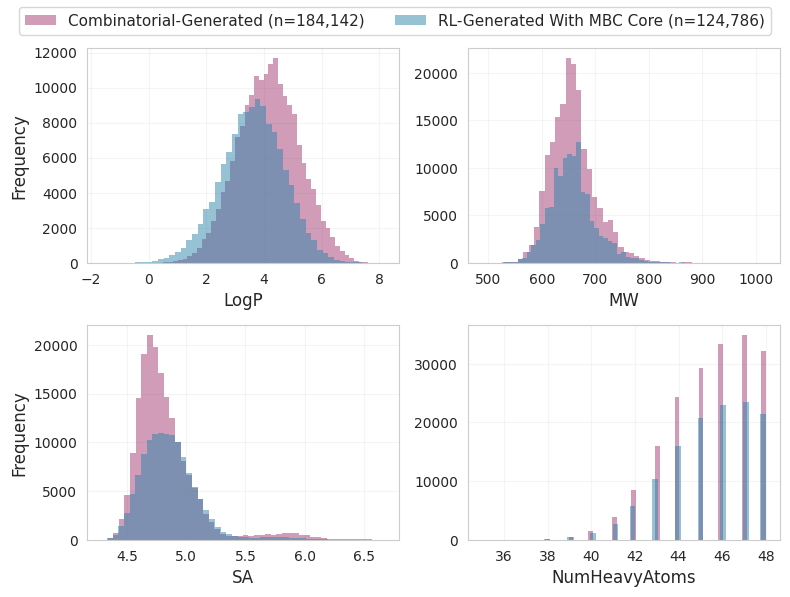

In [17]:
columns = ['LogP', 'MW', 'SA', 'NumHeavyAtoms']
fig, axes = plt.subplots(2, 2, figsize=(8, 6))
axes = axes.flatten()
 
for idx, col in enumerate(columns):
    ax = axes[idx]
    ax.hist(all_comb_hva[col], bins=50, alpha=0.5, label=f'Combinatorial-Generated (n={len(all_comb_hva[col]):,})', color=color_comb, linewidth=0)
    ax.hist(all_rl_hva[col], bins=50, alpha=0.5, label=f'RL-Generated With MBC Core (n={len(all_rl_hva[col]):,})', color=color_rl, linewidth=0)
    ax.set_xlabel(col, fontsize=12)
    ax.grid(True, alpha=0.2)

    if idx in [0, 2]: ax.set_ylabel('Frequency', fontsize=12)
    if col == 'NumHeavyAtoms': ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
    
handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=2, fontsize=11)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig(figure_dir + 'figure4_combinatorial_vs_rl_properties_dist.pdf', dpi=300, bbox_inches='tight', format='pdf')
plt.show()

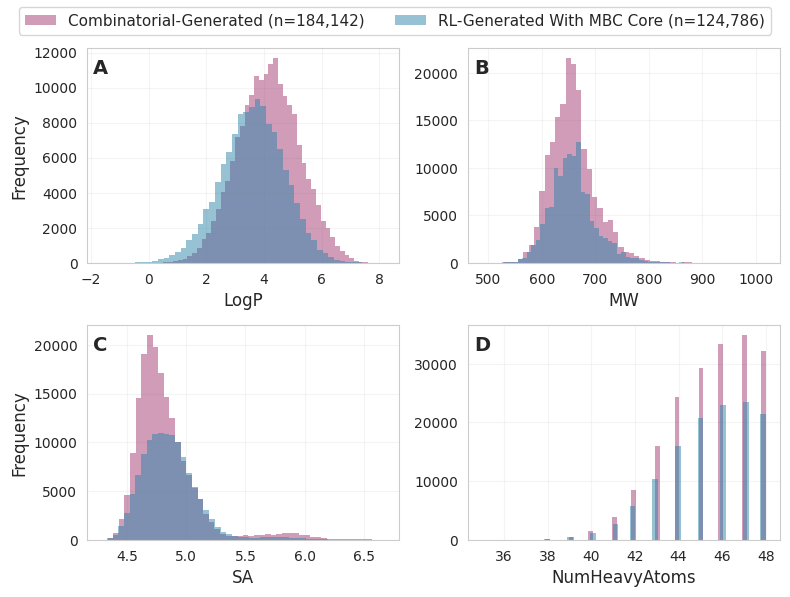

In [18]:
columns = ['LogP', 'MW', 'SA', 'NumHeavyAtoms']
fig, axes = plt.subplots(2, 2, figsize=(8, 6))
axes = axes.flatten()

labels_abcd = ['A', 'B', 'C', 'D']

for idx, col in enumerate(columns):
    ax = axes[idx]
    ax.hist(all_comb_hva[col], bins=50, alpha=0.5, label=f'Combinatorial-Generated (n={len(all_comb_hva[col]):,})', color=color_comb, linewidth=0)
    ax.hist(all_rl_hva[col], bins=50, alpha=0.5, label=f'RL-Generated With MBC Core (n={len(all_rl_hva[col]):,})', color=color_rl, linewidth=0)
    ax.set_xlabel(col, fontsize=12)
    ax.grid(True, alpha=0.2)

    if idx in [0, 2]: ax.set_ylabel('Frequency', fontsize=12)
    if col == 'NumHeavyAtoms': ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))

    ax.text(0.02, 0.95, labels_abcd[idx], transform=ax.transAxes,
            fontsize=14, fontweight='bold', va='top', ha='left')

handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=2, fontsize=11)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig(figure_dir + 'figure4_combinatorial_vs_rl_properties_dist_labeled.pdf', dpi=300, bbox_inches='tight', format='pdf')
plt.show()

### Archive

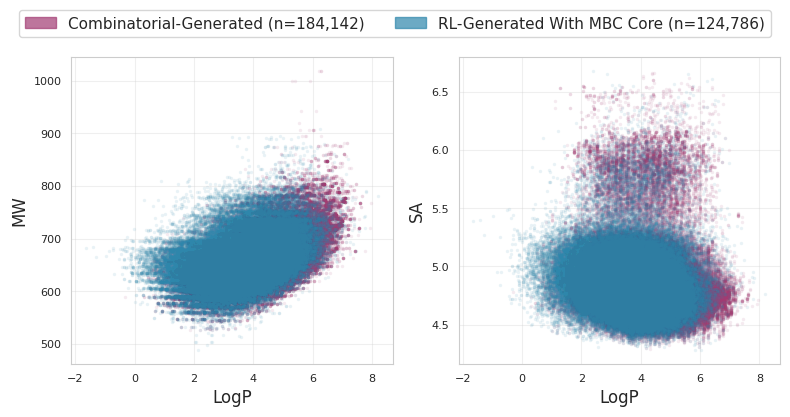

In [ ]:
# columns = ['LogP', 'MW', 'SA', ]
# pairs = [('LogP', 'MW'), ('LogP', 'SA')]

# fig, axes = plt.subplots(1, 2, figsize=(8, 4))

# for ax, (x_col, y_col) in zip(axes, pairs):
#     ax.scatter(all_comb_hva[x_col], all_comb_hva[y_col],
#                c=color_comb, alpha=0.1, s=6, linewidths=0)

#     ax.scatter(all_rl_hva[x_col], all_rl_hva[y_col],
#                c=color_rl, alpha=0.1, s=6, linewidths=0)

#     ax.set_xlabel(x_col, fontsize=12)
#     ax.set_ylabel(y_col, fontsize=12)
#     ax.tick_params(labelsize=8)
#     ax.grid(True, alpha=0.3)

# # Legend handles
# rl_patch = mpatches.Patch(
#     color=color_rl, alpha=0.7,
#     label=f'RL-Generated With MBC Core (n={len(all_rl_hva):,})'
# )
# comb_patch = mpatches.Patch(
#     color=color_comb, alpha=0.7,
#     label=f'Combinatorial-Generated (n={len(all_comb_hva):,})'
# )

# fig.legend(
#     handles=[comb_patch, rl_patch],
#     loc='upper center',
#     bbox_to_anchor=(0.5, 1.05),
#     ncol=2,
#     fontsize=11,
#     frameon=True
# )

# plt.tight_layout(rect=[0, 0, 1, 0.95])
# plt.savefig(figure_dir + 'fair_scatter_all.png', dpi=600, bbox_inches='tight', format='png')
# plt.show()

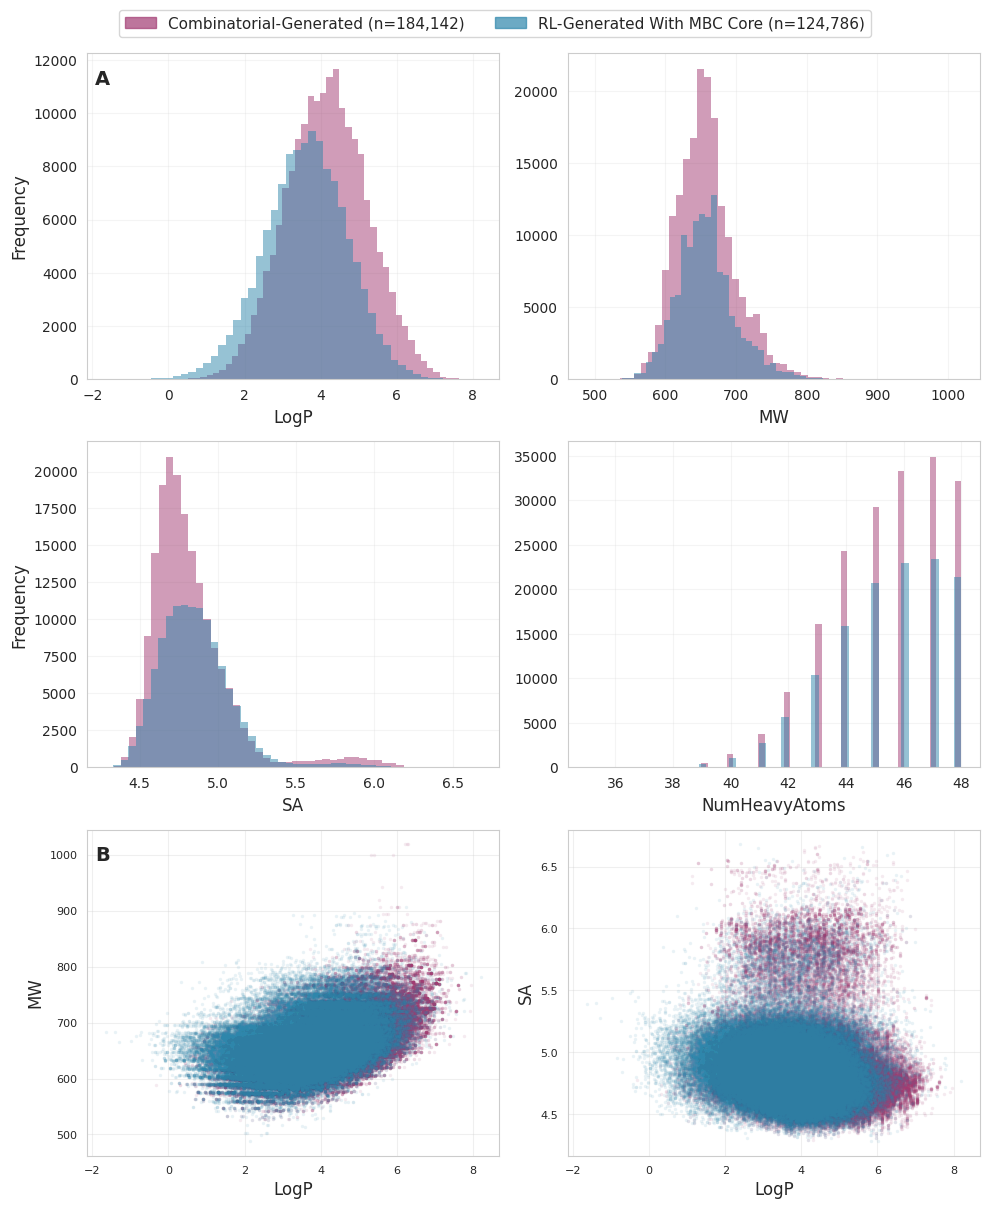

In [44]:
import matplotlib.patches as mpatches
import matplotlib.ticker as ticker

hist_columns = ['LogP', 'MW', 'SA', 'NumHeavyAtoms']
scatter_pairs = [('LogP', 'MW'), ('LogP', 'SA')]

fig, axes = plt.subplots(3, 2, figsize=(10, 12))

# ── Rows 0‑1: histograms ──────────────────────────────────────────────────────
hist_axes = [axes[0, 0], axes[0, 1], axes[1, 0], axes[1, 1]]

for idx, col in enumerate(hist_columns):
    ax = hist_axes[idx]
    ax.hist(all_comb_hva[col], bins=50, alpha=0.5,
            label=f'Combinatorial-Generated (n={len(all_comb_hva[col]):,})',
            color=color_comb, linewidth=0)
    ax.hist(all_rl_hva[col], bins=50, alpha=0.5,
            label=f'RL-Generated With MBC Core (n={len(all_rl_hva[col]):,})',
            color=color_rl, linewidth=0)
    ax.set_xlabel(col, fontsize=12)
    ax.grid(True, alpha=0.2)
    if idx in [0, 2]:
        ax.set_ylabel('Frequency', fontsize=12)
    if col == 'NumHeavyAtoms':
        ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))

hist_axes[0].text(0.02, 0.95, 'A', transform=hist_axes[0].transAxes,
                  fontsize=14, fontweight='bold', va='top', ha='left')

# ── Row 2: scatter plots ──────────────────────────────────────────────────────
scatter_axes = [axes[2, 0], axes[2, 1]]

for ax, (x_col, y_col) in zip(scatter_axes, scatter_pairs):
    ax.scatter(all_comb_hva[x_col], all_comb_hva[y_col],
               c=color_comb, alpha=0.1, s=6, linewidths=0)
    ax.scatter(all_rl_hva[x_col], all_rl_hva[y_col],
               c=color_rl, alpha=0.1, s=6, linewidths=0)
    ax.set_xlabel(x_col, fontsize=12)
    ax.set_ylabel(y_col, fontsize=12)
    ax.tick_params(labelsize=8)
    ax.grid(True, alpha=0.3)
    
scatter_axes[0].text(0.02, 0.95, 'B', transform=scatter_axes[0].transAxes,
                     fontsize=14, fontweight='bold', va='top', ha='left')

# ── Shared legend ─────────────────────────────────────────────────────────────
comb_patch = mpatches.Patch(color=color_comb, alpha=0.7,
                             label=f'Combinatorial-Generated (n={len(all_comb_hva):,})')
rl_patch   = mpatches.Patch(color=color_rl,   alpha=0.7,
                             label=f'RL-Generated With MBC Core (n={len(all_rl_hva):,})')

fig.legend(
    handles=[comb_patch, rl_patch],
    loc='upper center',
    bbox_to_anchor=(0.5, 1.01),
    ncol=2,
    fontsize=11,
    frameon=True
)

plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.savefig(figure_dir + 'fair_combined_all.png', dpi=300, bbox_inches='tight', format='png')
plt.show()

### Figure 5. Prop Dist Pareto1K

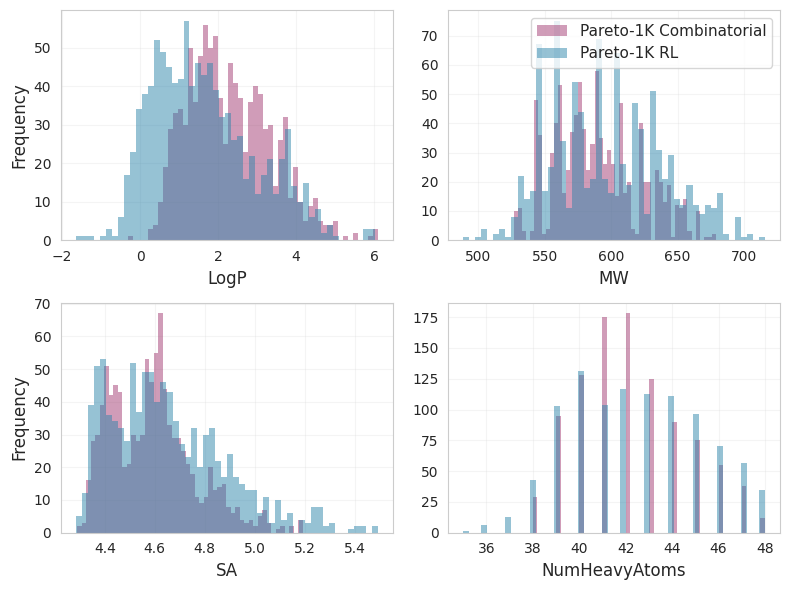

In [19]:
columns = ['LogP', 'MW', 'SA', 'NumHeavyAtoms']
fig, axes = plt.subplots(2, 2, figsize=(8, 6))
axes = axes.flatten()

for idx, col in enumerate(columns):
    ax = axes[idx]
    ax.hist(pareto_comb_1k_nodock[col], bins=50, alpha=0.5, label='Pareto-1K Combinatorial', color=color_comb, linewidth=0)
    ax.hist(pareto_rl_1k_nodock[col], bins=50, alpha=0.5, label='Pareto-1K RL', color=color_rl, linewidth=0)
    ax.set_xlabel(col, fontsize=12)
    ax.grid(True, alpha=0.2)

    if idx in [0, 2]: ax.set_ylabel('Frequency', fontsize=12)
    if idx == 1: ax.legend(fontsize=11)
    if col == 'NumHeavyAtoms': ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))

plt.tight_layout()
plt.savefig(figure_dir + 'figure5_pareto1k_properties_dist.pdf', dpi=300, bbox_inches='tight', format='pdf')
plt.show()

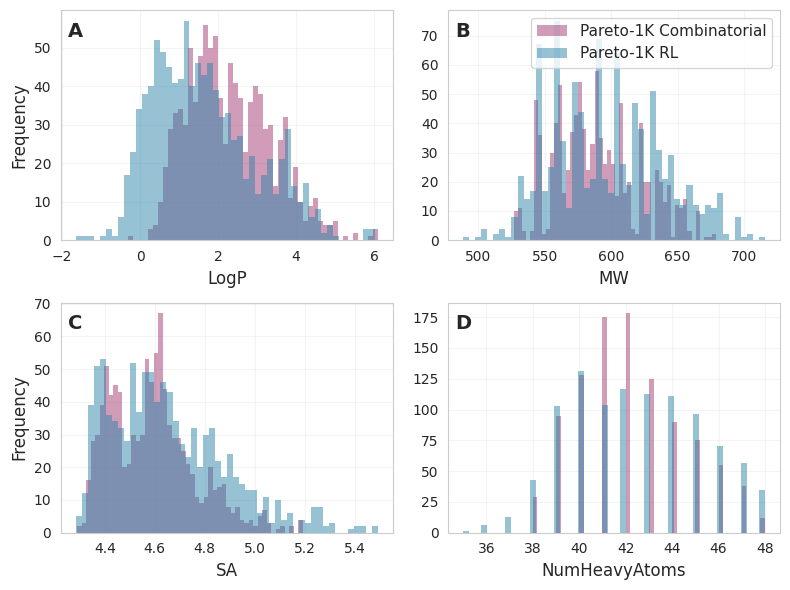

In [20]:
columns = ['LogP', 'MW', 'SA', 'NumHeavyAtoms']
fig, axes = plt.subplots(2, 2, figsize=(8, 6))
axes = axes.flatten()

labels_abcd = ['A', 'B', 'C', 'D']

for idx, col in enumerate(columns):
    ax = axes[idx]
    ax.hist(pareto_comb_1k_nodock[col], bins=50, alpha=0.5, label='Pareto-1K Combinatorial', color=color_comb, linewidth=0)
    ax.hist(pareto_rl_1k_nodock[col], bins=50, alpha=0.5, label='Pareto-1K RL', color=color_rl, linewidth=0)
    ax.set_xlabel(col, fontsize=12)
    ax.grid(True, alpha=0.2)
    ax.text(0.02, 0.95, labels_abcd[idx], transform=ax.transAxes,
            fontsize=14, fontweight='bold', va='top', ha='left')

    if idx in [0, 2]: ax.set_ylabel('Frequency', fontsize=12)
    if idx == 1: ax.legend(fontsize=11)
    if col == 'NumHeavyAtoms': ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))

plt.tight_layout()
plt.savefig(figure_dir + 'figure5_pareto1k_properties_dist_labeled.pdf', dpi=300, bbox_inches='tight', format='pdf')
plt.show()

### Figure 6. Binding Dist Pareto1K RL_Comb

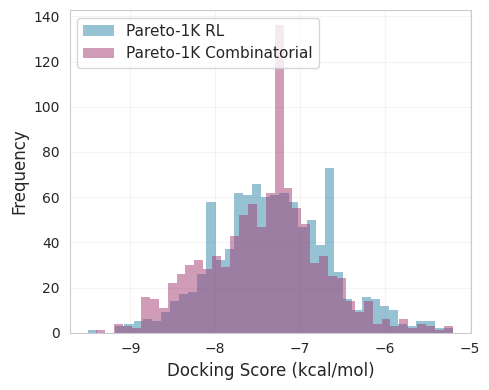

In [21]:
fig, ax = plt.subplots(figsize=(5, 4))

ax.hist(pareto_rl_1k_nodock['lowest_mode1_affinity'], bins=40, alpha=0.5, color=color_rl, label='Pareto-1K RL', linewidth=0.0)
ax.hist(pareto_comb_1k_nodock['lowest_mode1_affinity'], bins=40, alpha=0.5, color=color_comb, label='Pareto-1K Combinatorial', linewidth=0.0)
ax.set_xlabel('Docking Score (kcal/mol)', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.legend(fontsize=11, frameon=True, loc='upper left')
ax.grid(alpha=0.2)

plt.tight_layout()
plt.savefig(figure_dir + 'figure6_pareto1k_dockingscore_dist.pdf', dpi=300, bbox_inches='tight', format='pdf')
plt.show()

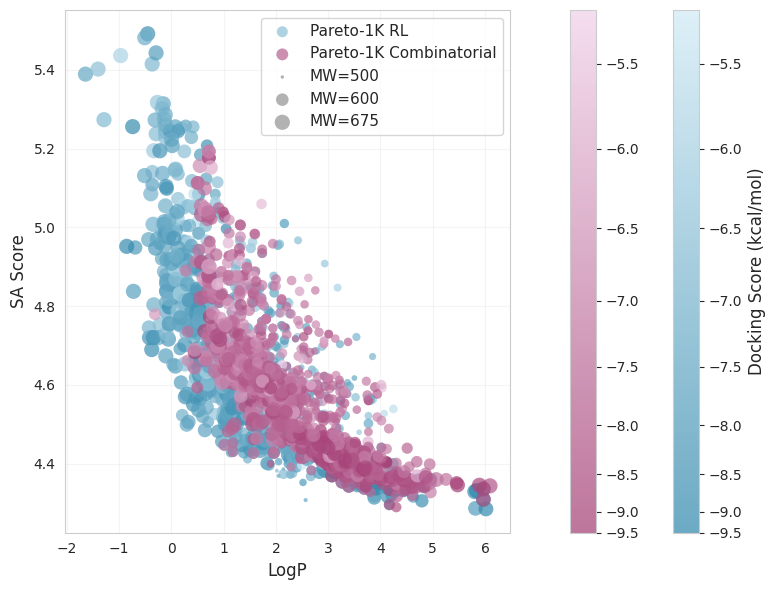

In [22]:
MW_MIN, MW_MAX = 500, 650
S_MIN, S_MAX = 6, 120

def mw_to_size(mw):
    return S_MIN + (mw.clip(MW_MIN, MW_MAX) - MW_MIN) / (MW_MAX - MW_MIN) * (S_MAX - S_MIN)

# Extract top 100 lowest binding affinity from each set
rl_df = pareto_rl_1k_nodock[['LogP', 'SA', 'lowest_mode1_affinity', 'MW']].dropna()
comb_df = pareto_comb_1k_nodock[['LogP', 'SA', 'lowest_mode1_affinity', 'MW']].dropna()

# Shared affinity range
vmin = min(rl_df['lowest_mode1_affinity'].min(), comb_df['lowest_mode1_affinity'].min())
vmax = max(rl_df['lowest_mode1_affinity'].max(), comb_df['lowest_mode1_affinity'].max())

# Power norm
norm = mcolors.PowerNorm(gamma=1.5, vmin=vmin, vmax=vmax)
cmap_rl   = mcolors.LinearSegmentedColormap.from_list('rl',   [color_rl, '#d0eaf5'])
cmap_comb = mcolors.LinearSegmentedColormap.from_list('comb', [color_comb, '#f0d0e8'])

size_rl   = mw_to_size(rl_df['MW'])
size_comb = mw_to_size(comb_df['MW'])

fig, ax = plt.subplots(figsize=(8, 6))

sc_rl = ax.scatter(
    rl_df['LogP'], rl_df['SA'],
    c=rl_df['lowest_mode1_affinity'], cmap=cmap_rl, norm=norm,
    alpha=0.7, edgecolors='none', s=size_rl, label='Pareto-1K RL'
)

sc_comb = ax.scatter(
    comb_df['LogP'], comb_df['SA'],
    c=comb_df['lowest_mode1_affinity'], cmap=cmap_comb, norm=norm,
    alpha=0.7, edgecolors='none', s=size_comb, label='Pareto-1K Combinatorial'
)

cbar_rl = plt.colorbar(sc_rl, ax=ax, pad=0.02)
cbar_rl.set_label('Docking Score (kcal/mol)', fontsize=12)

cbar_comb = plt.colorbar(sc_comb, ax=ax, pad=0.1)

# MW size legend
for mw_val in [500, 600, 675]:
    ax.scatter([], [], s=mw_to_size(pd.Series([mw_val]))[0],
               color='gray', alpha=0.6, edgecolors='none',
               label=f'MW={mw_val}')

ax.set_xlabel('LogP', fontsize=12)
ax.set_ylabel('SA Score', fontsize=12)
ax.legend(fontsize=11, frameon=True)
ax.grid(alpha=0.2)
plt.tight_layout()
plt.savefig(figure_dir + "figure6_pareto1k_scatter.pdf", dpi=300, bbox_inches='tight', format='pdf')
plt.show()

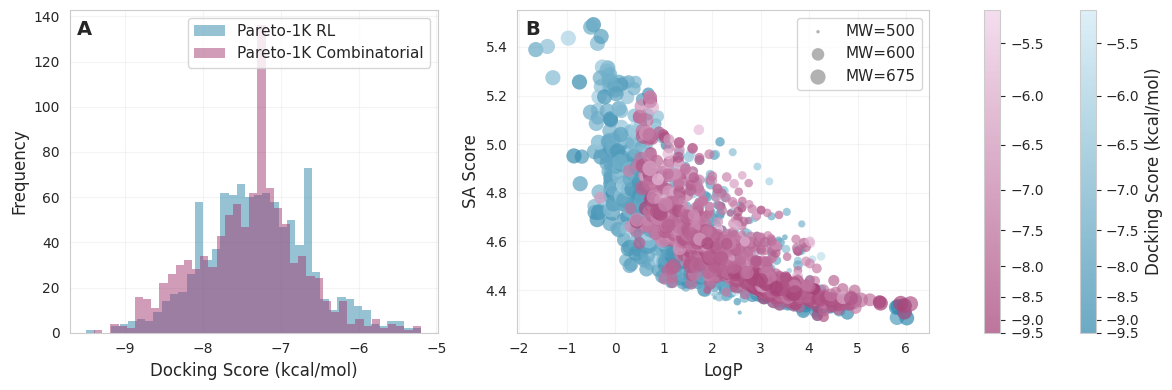

In [29]:
MW_MIN, MW_MAX = 500, 650
S_MIN, S_MAX = 6, 120

def mw_to_size(mw):
    return S_MIN + (mw.clip(MW_MIN, MW_MAX) - MW_MIN) / (MW_MAX - MW_MIN) * (S_MAX - S_MIN)

# Extract top 100 lowest binding affinity from each set
rl_df = pareto_rl_1k_nodock[['LogP', 'SA', 'lowest_mode1_affinity', 'MW']].dropna()
comb_df = pareto_comb_1k_nodock[['LogP', 'SA', 'lowest_mode1_affinity', 'MW']].dropna()

# Shared affinity range
vmin = min(rl_df['lowest_mode1_affinity'].min(), comb_df['lowest_mode1_affinity'].min())
vmax = max(rl_df['lowest_mode1_affinity'].max(), comb_df['lowest_mode1_affinity'].max())

norm = mcolors.PowerNorm(gamma=1.5, vmin=vmin, vmax=vmax)
cmap_rl   = mcolors.LinearSegmentedColormap.from_list('rl',   [color_rl, '#d0eaf5'])
cmap_comb = mcolors.LinearSegmentedColormap.from_list('comb', [color_comb, '#f0d0e8'])

size_rl   = mw_to_size(rl_df['MW'])
size_comb = mw_to_size(comb_df['MW'])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4), gridspec_kw={'width_ratios': [1, 1.8]})

# ── Left panel: histogram ──────────────────────────────────────────────────
ax1.hist(pareto_rl_1k_nodock['lowest_mode1_affinity'],   bins=40, alpha=0.5, color=color_rl,   label='Pareto-1K RL',            linewidth=0.0)
ax1.hist(pareto_comb_1k_nodock['lowest_mode1_affinity'], bins=40, alpha=0.5, color=color_comb, label='Pareto-1K Combinatorial',  linewidth=0.0)
ax1.set_xlabel('Docking Score (kcal/mol)', fontsize=12)
ax1.set_ylabel('Frequency', fontsize=12)
ax1.legend(fontsize=11, frameon=True, loc='upper right')
ax1.text(0.02, 0.97, 'A', transform=ax1.transAxes, fontsize=14, fontweight='bold', va='top')
ax1.grid(alpha=0.2)

# ── Right panel: scatter ───────────────────────────────────────────────────
sc_rl = ax2.scatter(
    rl_df['LogP'], rl_df['SA'],
    c=rl_df['lowest_mode1_affinity'], cmap=cmap_rl, norm=norm,
    alpha=0.7, edgecolors='none', s=size_rl,
)
sc_comb = ax2.scatter(
    comb_df['LogP'], comb_df['SA'],
    c=comb_df['lowest_mode1_affinity'], cmap=cmap_comb, norm=norm,
    alpha=0.7, edgecolors='none', s=size_comb, 
)

cbar_rl   = plt.colorbar(sc_rl,   ax=ax2, pad=0.02)
cbar_rl.set_label('Docking Score (kcal/mol)', fontsize=12)
cbar_comb = plt.colorbar(sc_comb, ax=ax2, pad=0.1)

# MW size legend entries
for mw_val in [500, 600, 675]:
    ax2.scatter([], [], s=mw_to_size(pd.Series([mw_val]))[0],
                color='gray', alpha=0.6, edgecolors='none',
                label=f'MW={mw_val}')

ax2.set_xlabel('LogP', fontsize=12)
ax2.set_ylabel('SA Score', fontsize=12)
ax2.legend(fontsize=11, frameon=True)
ax2.text(0.02, 0.97, 'B', transform=ax2.transAxes, fontsize=14, fontweight='bold', va='top')
ax2.grid(alpha=0.2)

plt.tight_layout()
plt.savefig(figure_dir + 'figure6_pareto1k_all.pdf', dpi=300, bbox_inches='tight', format='pdf')
plt.show()

### Archive

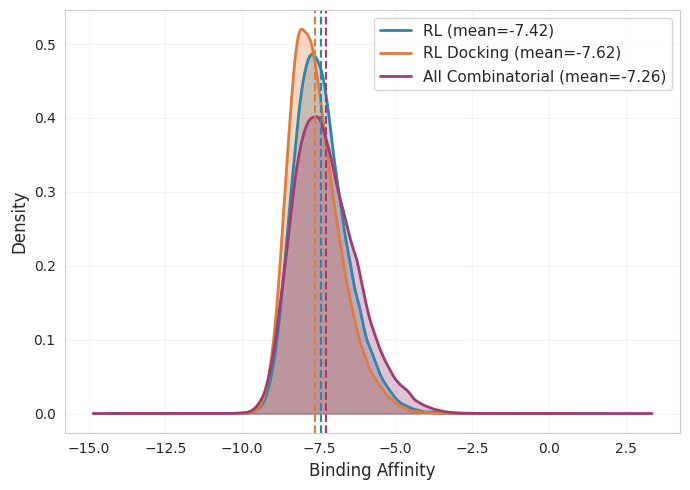

In [19]:
fig, ax = plt.subplots(figsize=(7, 5))

all_rl_affinity = all_rl_hva['lowest_mode1_affinity'].dropna()
all_rl_docking_affinity = all_rl_docking_hva['lowest_mode1_affinity'].dropna()
all_combinatorial_affinity = all_comb_hva['lowest_mode1_affinity'].dropna()

all_rl_affinity.plot.kde(ax=ax, color=color_rl, linewidth=2, label=f'RL (mean={all_rl_affinity.mean():.2f})')
all_rl_docking_affinity.plot.kde(ax=ax, color=color_rl_docking, linewidth=2, label=f'RL Docking (mean={all_rl_docking_affinity.mean():.2f})')
all_combinatorial_affinity.plot.kde(ax=ax, color=color_comb, linewidth=2, label=f'All Combinatorial (mean={all_combinatorial_affinity.mean():.2f})')

kdeline_rl = ax.lines[0]
kdeline_rl_docking = ax.lines[1]
kdeline_all_comb = ax.lines[2]

ax.fill_between(kdeline_rl.get_xdata(), kdeline_rl.get_ydata(), alpha=0.3, color=color_rl)
ax.fill_between(kdeline_rl_docking.get_xdata(), kdeline_rl_docking.get_ydata(), alpha=0.3, color=color_rl_docking)
ax.fill_between(kdeline_all_comb.get_xdata(), kdeline_all_comb.get_ydata(), alpha=0.3, color=color_comb)

ax.axvline(all_rl_affinity.mean(), color=color_rl, linestyle='--', linewidth=1.5)
ax.axvline(all_rl_docking_affinity.mean(), color=color_rl_docking, linestyle='--', linewidth=1.5)
ax.axvline(all_combinatorial_affinity.mean(), color=color_comb, linestyle='--', linewidth=1.5)

ax.set_xlabel('Binding Affinity', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.legend(fontsize=11, frameon=True)
ax.grid(alpha=0.2)

plt.tight_layout()
plt.savefig(figure_dir + "fair_binding_dist_all_rl_rldocking_comb.pdf", dpi=600, bbox_inches='tight', format='pdf')
plt.show()

/tmp/ipykernel_3994722/635405298.py:32: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot(plot_data, patch_artist=True, labels=labels, widths=0.5)


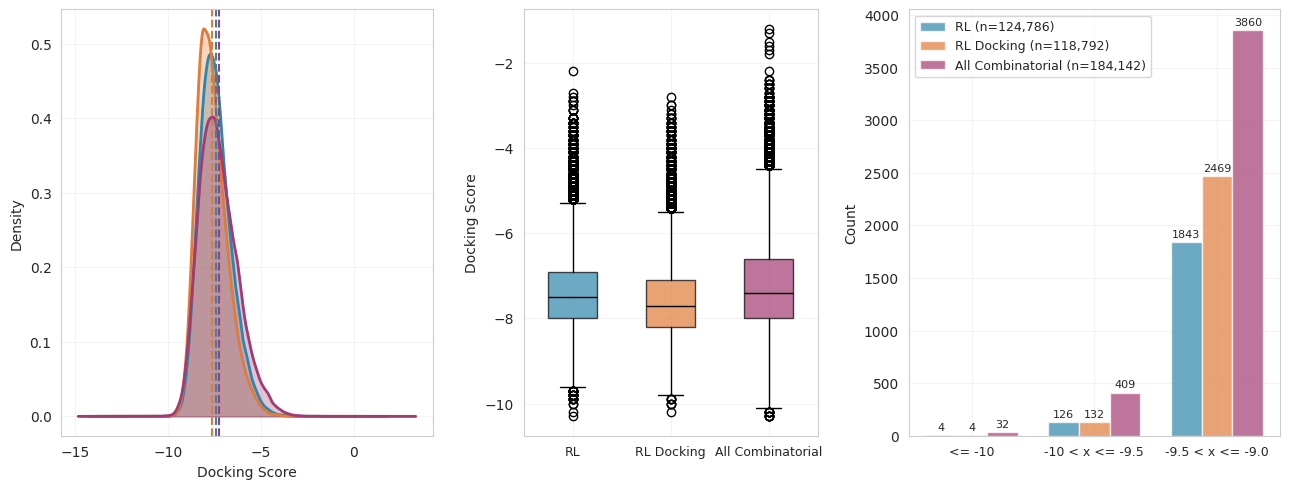

In [3]:
fig, axes = plt.subplots(
    1, 3,
    figsize=(13, 5),
    gridspec_kw={'width_ratios': [1.2, 0.95, 1.2]}  # middle is smaller
)
all_rl_affinity = all_rl_hva['lowest_mode1_affinity'].dropna()
all_rl_docking_affinity = all_rl_docking_hva['lowest_mode1_affinity'].dropna()
all_combinatorial_affinity = all_comb_hva['lowest_mode1_affinity'].dropna()

plot_data = [all_rl_affinity, all_rl_docking_affinity, all_combinatorial_affinity]
labels = [f'RL (n={len(all_rl_affinity):,})', f'RL Docking (n={len(all_rl_docking_affinity):,})', f'All Combinatorial (n={len(all_combinatorial_affinity):,})']
xlabels = ['RL', 'RL Docking', 'All Combinatorial']
colors = [color_rl, color_rl_docking, color_comb]

# --- KDE Plot (1st subplot) ---
for affinity, label, color in zip(plot_data, labels, colors):
    affinity.plot.kde(ax=axes[0], color=color, linewidth=2)

lines = axes[0].lines
for line, color in zip(lines, colors):
    axes[0].fill_between(line.get_xdata(), line.get_ydata(), alpha=0.3, color=color)
for affinity, color in zip(plot_data, colors):
    axes[0].axvline(affinity.mean(), color=color, linestyle='--', linewidth=1.5)

axes[0].set_xlabel('Docking Score', fontsize=10)
axes[0].set_ylabel('Density', fontsize=10)
# axes[0].set_title('KDE Distribution', fontsize=11)
# axes[0].legend(fontsize=9, frameon=True)
axes[0].grid(alpha=0.2)

# --- Boxplot (2nd subplot) ---
bp = axes[1].boxplot(plot_data, patch_artist=True, labels=labels, widths=0.5)
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
for median in bp['medians']:
    median.set_color('black')
# axes[1].set_title('Boxplot', fontsize=11)
axes[1].set_xticklabels(xlabels, fontsize=9)
axes[1].set_ylabel('Docking Score', fontsize=10)
axes[1].tick_params(axis='x', labelsize=9)
axes[1].grid(alpha=0.2)

# --- Bar chart (3rd subplot) ---
bins = {
    '<= -10': lambda x: (x <= -10).sum(),
    '-10 < x <= -9.5': lambda x: ((x > -10) & (x <= -9.5)).sum(),
    '-9.5 < x <= -9.0': lambda x: ((x > -9.5) & (x <= -9.0)).sum(),
}

x = np.arange(len(bins))
width = 0.25

for i, (affinity, label, color) in enumerate(zip(plot_data, labels, colors)):
    counts = [fn(affinity) for fn in bins.values()]
    bars = axes[2].bar(x + i * width, counts, width=width, label=label, color=color, alpha=0.7)
    axes[2].bar_label(bars, fmt='%d', fontsize=8, padding=2)

axes[2].set_xticks(x + width)
axes[2].set_xticklabels(bins.keys(), fontsize=9)
# axes[2].set_title('Count by Affinity Range', fontsize=11)
axes[2].set_ylabel('Count', fontsize=10)
axes[2].legend(fontsize=9, frameon=True)
axes[2].grid(alpha=0.2)

plt.tight_layout()
plt.savefig(figure_dir + 'fair_binding_analysis_all.pdf', dpi=600, bbox_inches='tight', format='pdf')
plt.show()

In [ ]:
# MW_MIN, MW_MAX = 500, 675
# S_MIN, S_MAX = 6, 120

# def mw_to_size(mw):
#     return S_MIN + (mw.clip(MW_MIN, MW_MAX) - MW_MIN) / (MW_MAX - MW_MIN) * (S_MAX - S_MIN)


# # Keep only needed columns and valid rows
# cols = ['LogP', 'SA', 'lowest_mode1_affinity', 'MW']
# rl_df = pareto_rl_1stfront_docking[cols].dropna().copy()
# rl_docking_df = pareto_rl_docking_1stfront_docking[cols].dropna().copy()
# comb_df = pareto_comb_1stfront_docking[cols].dropna().copy()

# # Shared affinity range across all 3 sets
# vmin = min(
#     rl_df['lowest_mode1_affinity'].min(),
#     rl_docking_df['lowest_mode1_affinity'].min(),
#     comb_df['lowest_mode1_affinity'].min()
# )
# vmax = max(
#     rl_df['lowest_mode1_affinity'].max(),
#     rl_docking_df['lowest_mode1_affinity'].max(),
#     comb_df['lowest_mode1_affinity'].max()
# )

# norm = mcolors.PowerNorm(gamma=1.5, vmin=vmin, vmax=vmax)
# cmap_rl = mcolors.LinearSegmentedColormap.from_list('rl', [color_rl, '#d0eaf5'])
# cmap_rl_docking = mcolors.LinearSegmentedColormap.from_list('rl_docking', [color_rl_docking, '#fbe4d3'])
# cmap_comb = mcolors.LinearSegmentedColormap.from_list('comb', [color_comb, '#f0d0e8'])

# size_rl = mw_to_size(rl_df['MW'])
# size_rl_docking = mw_to_size(rl_docking_df['MW'])
# size_comb = mw_to_size(comb_df['MW'])

# fig, ax = plt.subplots(figsize=(8, 6))

# # Circle markers only (default marker='o')
# sc_rl = ax.scatter(
#     rl_df['LogP'], rl_df['SA'],
#     c=rl_df['lowest_mode1_affinity'], cmap=cmap_rl, norm=norm,
#     alpha=0.7, edgecolors='none', s=size_rl, label=f'Latent RL (n={len(rl_df):,})'
# )

# sc_rl_docking = ax.scatter(
#     rl_docking_df['LogP'], rl_docking_df['SA'],
#     c=rl_docking_df['lowest_mode1_affinity'], cmap=cmap_rl_docking, norm=norm,
#     alpha=0.7, edgecolors='none', s=size_rl_docking, label=f'Latent RL Docking (n={len(rl_docking_df):,})'
# )

# sc_comb = ax.scatter(
#     comb_df['LogP'], comb_df['SA'],
#     c=comb_df['lowest_mode1_affinity'], cmap=cmap_comb, norm=norm,
#     alpha=0.7, edgecolors='none', s=size_comb, label=f'Combinatorial (n={len(comb_df):,})'
# )

# cbar = plt.colorbar(sc_rl, ax=ax, pad=0.02)
# cbar.set_label('Binding Affinity', fontsize=10)

# # MW size legend
# for mw_val in [550, 600, 675]:
#     ax.scatter([], [], s=mw_to_size(pd.Series([mw_val])).iloc[0],
#                color='gray', alpha=0.6, edgecolors='none', label=f'MW={mw_val}')

# ax.set_xlabel('LogP', fontsize=11)
# ax.set_ylabel('SA Score', fontsize=11)
# # ax.set_title('Pareto: LogP vs SA Score', fontsize=12)
# ax.legend(fontsize=9, frameon=True, loc='best')
# ax.grid(alpha=0.2)

# plt.tight_layout()
# plt.savefig(figure_dir + 'fair_scatter_pareto_1stfront_all.pdf', dpi=600, bbox_inches='tight', format='pdf')
# plt.show()

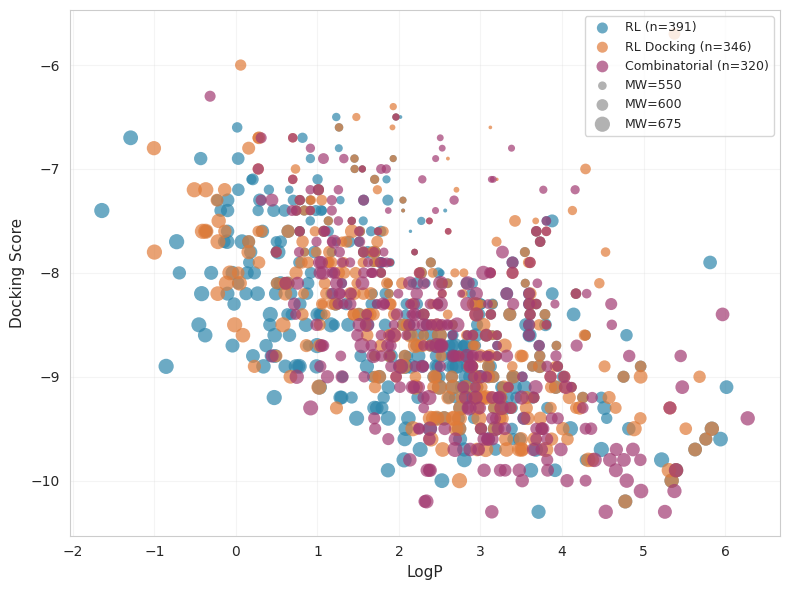

In [40]:
MW_MIN, MW_MAX = 500, 675
S_MIN, S_MAX = 6, 120

def mw_to_size(mw):
    return S_MIN + (mw.clip(MW_MIN, MW_MAX) - MW_MIN) / (MW_MAX - MW_MIN) * (S_MAX - S_MIN)


# Keep only needed columns and valid rows
cols = ['LogP', 'lowest_mode1_affinity', 'MW']
rl_df = pareto_rl_1stfront_docking[cols].dropna().copy()
rl_docking_df = pareto_rl_docking_1stfront_docking[cols].dropna().copy()
comb_df = pareto_comb_1stfront_docking[cols].dropna().copy()

size_rl = mw_to_size(rl_df['MW'])
size_rl_docking = mw_to_size(rl_docking_df['MW'])
size_comb = mw_to_size(comb_df['MW'])

fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(
    rl_df['LogP'], rl_df['lowest_mode1_affinity'],
    color=color_rl, alpha=0.7, edgecolors='none', s=size_rl,
    label=f'RL (n={len(rl_df):,})'
)

ax.scatter(
    rl_docking_df['LogP'], rl_docking_df['lowest_mode1_affinity'],
    color=color_rl_docking, alpha=0.7, edgecolors='none', s=size_rl_docking,
    label=f'RL Docking (n={len(rl_docking_df):,})'
)

ax.scatter(
    comb_df['LogP'], comb_df['lowest_mode1_affinity'],
    color=color_comb, alpha=0.7, edgecolors='none', s=size_comb,
    label=f'Combinatorial (n={len(comb_df):,})'
)

# MW size legend
for mw_val in [550, 600, 675]:
    ax.scatter([], [], s=mw_to_size(pd.Series([mw_val])).iloc[0],
               color='gray', alpha=0.6, edgecolors='none', label=f'MW={mw_val}')

ax.set_xlabel('LogP', fontsize=11)
ax.set_ylabel('Docking Score', fontsize=11)
# ax.set_title('Pareto: LogP vs Docking Score', fontsize=12)
ax.legend(fontsize=9, frameon=True, loc='upper right')
ax.grid(alpha=0.2)

plt.tight_layout()
plt.savefig(figure_dir + 'fair_scatter_pareto_1stfront_all.pdf', dpi=600, bbox_inches='tight', format='pdf')
plt.show()

###  Figure 7

/tmp/ipykernel_3871947/1945246674.py:46: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax1.boxplot(plot_data, patch_artist=True, labels=labels, widths=0.5)


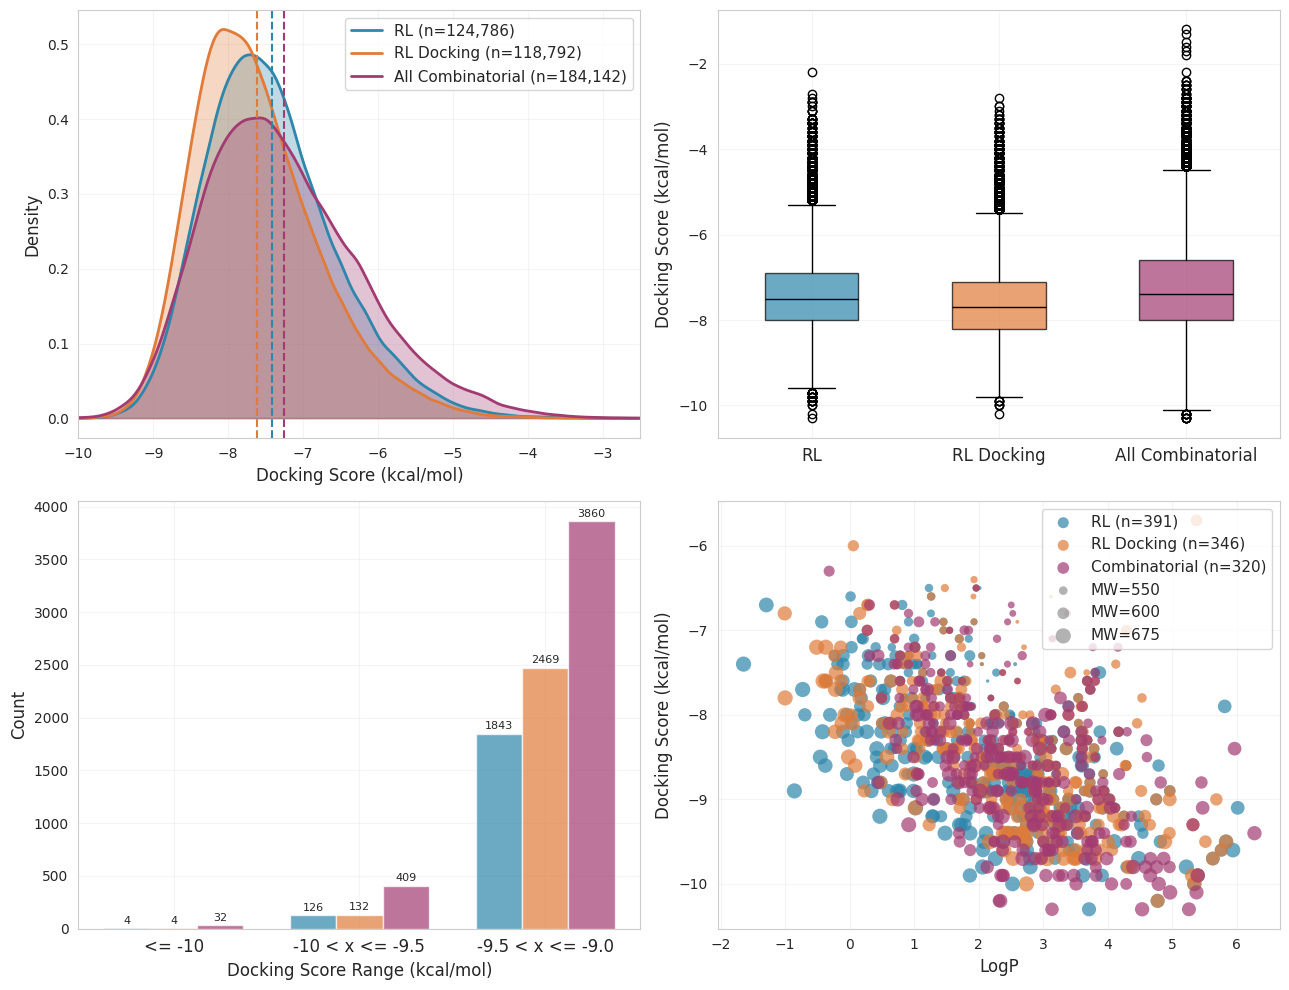

In [26]:
MW_MIN, MW_MAX = 500, 675
S_MIN, S_MAX = 6, 120

def mw_to_size(mw):
    return S_MIN + (mw.clip(MW_MIN, MW_MAX) - MW_MIN) / (MW_MAX - MW_MIN) * (S_MAX - S_MIN)

# --- Data prep ---
all_rl_affinity = all_rl_hva['lowest_mode1_affinity'].dropna()
all_rl_docking_affinity = all_rl_docking_hva['lowest_mode1_affinity'].dropna()
all_combinatorial_affinity = all_comb_hva['lowest_mode1_affinity'].dropna()

plot_data = [all_rl_affinity, all_rl_docking_affinity, all_combinatorial_affinity]
labels = [f'RL (n={len(all_rl_affinity):,})', f'RL Docking (n={len(all_rl_docking_affinity):,})', f'All Combinatorial (n={len(all_combinatorial_affinity):,})']
xlabels = ['RL', 'RL Docking', 'All Combinatorial']
colors = [color_rl, color_rl_docking, color_comb]

cols = ['LogP', 'lowest_mode1_affinity', 'MW']
rl_df = pareto_rl_1stfront_docking[cols].dropna().copy()
rl_docking_df = pareto_rl_docking_1stfront_docking[cols].dropna().copy()
comb_df = pareto_comb_1stfront_docking[cols].dropna().copy()

size_rl = mw_to_size(rl_df['MW'])
size_rl_docking = mw_to_size(rl_docking_df['MW'])
size_comb = mw_to_size(comb_df['MW'])

# --- 2x2 Figure ---
fig, axes = plt.subplots(2, 2, figsize=(13, 10))
ax0, ax1, ax2, ax3 = axes.flatten()

# --- (A) KDE Plot ---
for affinity, label, color in zip(plot_data, labels, colors):
    affinity.plot.kde(ax=ax0, color=color, linewidth=2, label=label)

for line, color in zip(ax0.lines, colors):
    ax0.fill_between(line.get_xdata(), line.get_ydata(), alpha=0.3, color=color)
for affinity, color in zip(plot_data, colors):
    ax0.axvline(affinity.mean(), color=color, linestyle='--', linewidth=1.5)

ax0.set_xlabel('Docking Score (kcal/mol)', fontsize=12)
ax0.set_ylabel('Density', fontsize=12)
ax0.set_xlim(-10, -2.5)
ax0.legend(fontsize=11, frameon=True, loc='upper right')
ax0.grid(alpha=0.2)

# --- (B) Boxplot ---
bp = ax1.boxplot(plot_data, patch_artist=True, labels=labels, widths=0.5)
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
for median in bp['medians']:
    median.set_color('black')

ax1.set_xticklabels(xlabels, fontsize=12)
ax1.set_ylabel('Docking Score (kcal/mol)', fontsize=12)
ax1.tick_params(axis='x', labelsize=12)
ax1.grid(alpha=0.2)

# --- (C) Bar Chart ---
bins = {
    '<= -10': lambda x: (x <= -10).sum(),
    '-10 < x <= -9.5': lambda x: ((x > -10) & (x <= -9.5)).sum(),
    '-9.5 < x <= -9.0': lambda x: ((x > -9.5) & (x <= -9.0)).sum(),
}

x = np.arange(len(bins))
width = 0.25

for i, (affinity, label, color) in enumerate(zip(plot_data, labels, colors)):
    counts = [fn(affinity) for fn in bins.values()]
    bars = ax2.bar(x + i * width, counts, width=width, label=label, color=color, alpha=0.7)
    ax2.bar_label(bars, fmt='%d', fontsize=8, padding=2)

ax2.set_xticks(x + width)
ax2.set_xticklabels(bins.keys(), fontsize=12)
ax2.set_ylabel('Count', fontsize=12)
ax2.set_xlabel('Docking Score Range (kcal/mol)', fontsize=12)
ax2.grid(alpha=0.2)

# --- (D) Scatter Plot ---
ax3.scatter(rl_df['LogP'], rl_df['lowest_mode1_affinity'],
            color=color_rl, alpha=0.7, edgecolors='none', s=size_rl,
            label=f'RL (n={len(rl_df):,})')
ax3.scatter(rl_docking_df['LogP'], rl_docking_df['lowest_mode1_affinity'],
            color=color_rl_docking, alpha=0.7, edgecolors='none', s=size_rl_docking,
            label=f'RL Docking (n={len(rl_docking_df):,})')
ax3.scatter(comb_df['LogP'], comb_df['lowest_mode1_affinity'],
            color=color_comb, alpha=0.7, edgecolors='none', s=size_comb,
            label=f'Combinatorial (n={len(comb_df):,})')

for mw_val in [550, 600, 675]:
    ax3.scatter([], [], s=mw_to_size(pd.Series([mw_val])).iloc[0],
                color='gray', alpha=0.6, edgecolors='none', label=f'MW={mw_val}')

ax3.set_xlabel('LogP', fontsize=12)
ax3.set_ylabel('Docking Score (kcal/mol)', fontsize=12)
ax3.legend(fontsize=11, frameon=True, loc='upper right')
ax3.grid(alpha=0.2)

plt.tight_layout()
plt.savefig(figure_dir + 'figure7_dist_boxplot_bar_scatter.pdf', dpi=300, bbox_inches='tight', format='pdf')
plt.show()

/tmp/ipykernel_3871947/2514676779.py:47: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax1.boxplot(plot_data, patch_artist=True, labels=labels, widths=0.5)


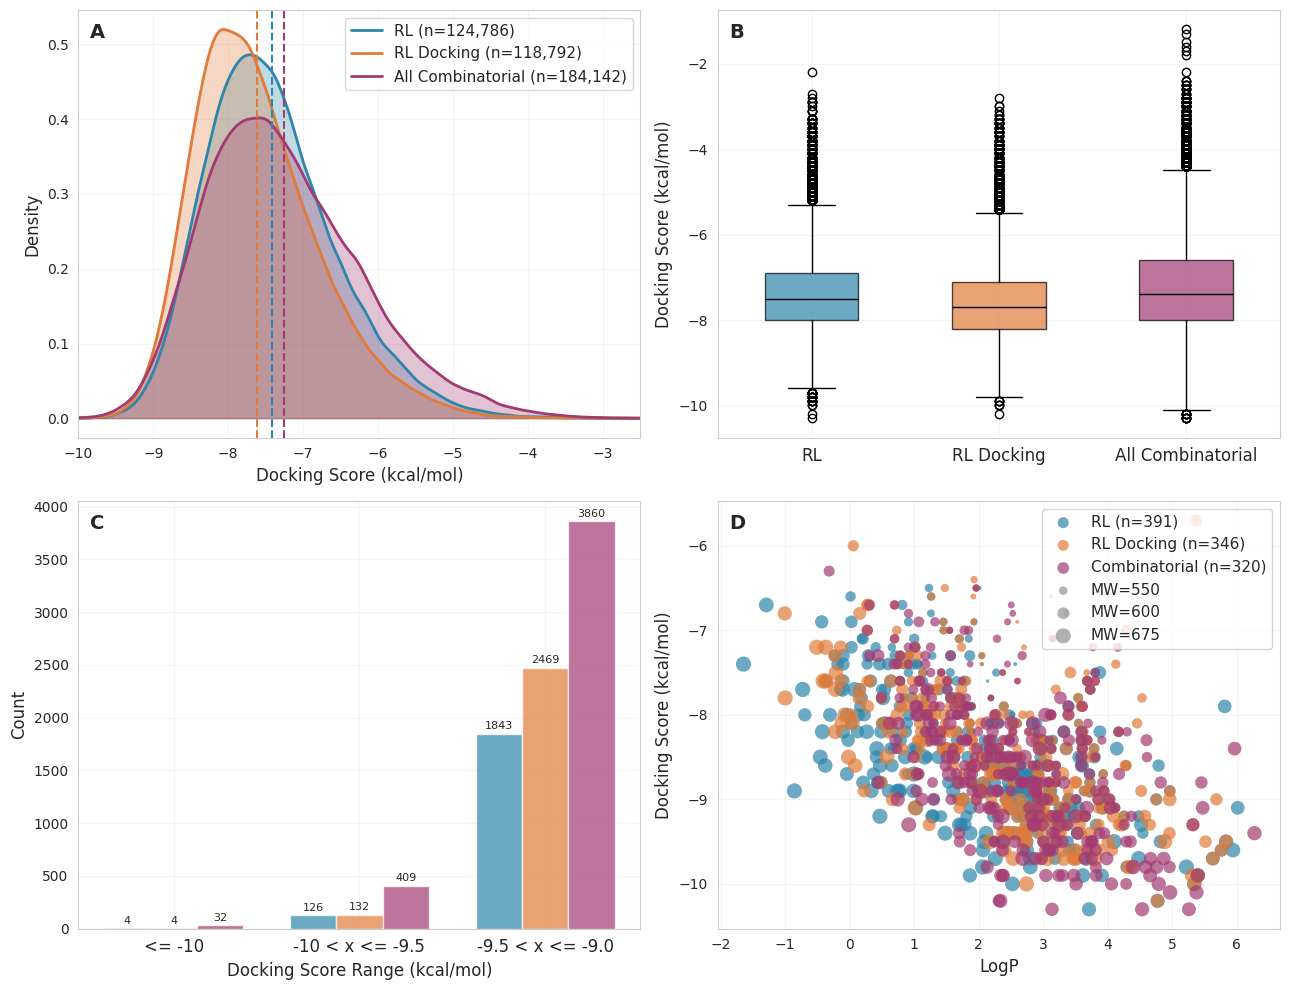

In [27]:
MW_MIN, MW_MAX = 500, 675
S_MIN, S_MAX = 6, 120

def mw_to_size(mw):
    return S_MIN + (mw.clip(MW_MIN, MW_MAX) - MW_MIN) / (MW_MAX - MW_MIN) * (S_MAX - S_MIN)

# --- Data prep ---
all_rl_affinity = all_rl_hva['lowest_mode1_affinity'].dropna()
all_rl_docking_affinity = all_rl_docking_hva['lowest_mode1_affinity'].dropna()
all_combinatorial_affinity = all_comb_hva['lowest_mode1_affinity'].dropna()

plot_data = [all_rl_affinity, all_rl_docking_affinity, all_combinatorial_affinity]
labels = [f'RL (n={len(all_rl_affinity):,})', f'RL Docking (n={len(all_rl_docking_affinity):,})', f'All Combinatorial (n={len(all_combinatorial_affinity):,})']
xlabels = ['RL', 'RL Docking', 'All Combinatorial']
colors = [color_rl, color_rl_docking, color_comb]

cols = ['LogP', 'lowest_mode1_affinity', 'MW']
rl_df = pareto_rl_1stfront_docking[cols].dropna().copy()
rl_docking_df = pareto_rl_docking_1stfront_docking[cols].dropna().copy()
comb_df = pareto_comb_1stfront_docking[cols].dropna().copy()

size_rl = mw_to_size(rl_df['MW'])
size_rl_docking = mw_to_size(rl_docking_df['MW'])
size_comb = mw_to_size(comb_df['MW'])

# --- 2x2 Figure ---
fig, axes = plt.subplots(2, 2, figsize=(13, 10))
ax0, ax1, ax2, ax3 = axes.flatten()

# --- (A) KDE Plot ---
for affinity, label, color in zip(plot_data, labels, colors):
    affinity.plot.kde(ax=ax0, color=color, linewidth=2, label=label)

for line, color in zip(ax0.lines, colors):
    ax0.fill_between(line.get_xdata(), line.get_ydata(), alpha=0.3, color=color)
for affinity, color in zip(plot_data, colors):
    ax0.axvline(affinity.mean(), color=color, linestyle='--', linewidth=1.5)

ax0.set_xlabel('Docking Score (kcal/mol)', fontsize=12)
ax0.set_ylabel('Density', fontsize=12)
ax0.set_xlim(-10, -2.5)
ax0.text(0.02, 0.97, 'A', transform=ax0.transAxes, fontsize=14, fontweight='bold', va='top', ha='left')
ax0.legend(fontsize=11, frameon=True, loc='upper right')
ax0.grid(alpha=0.2)

# --- (B) Boxplot ---
bp = ax1.boxplot(plot_data, patch_artist=True, labels=labels, widths=0.5)
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
for median in bp['medians']:
    median.set_color('black')

ax1.set_xticklabels(xlabels, fontsize=12)
ax1.set_ylabel('Docking Score (kcal/mol)', fontsize=12)
ax1.tick_params(axis='x', labelsize=12)
ax1.text(0.02, 0.97, 'B', transform=ax1.transAxes, fontsize=14, fontweight='bold', va='top', ha='left')
ax1.grid(alpha=0.2)

# --- (C) Bar Chart ---
bins = {
    '<= -10': lambda x: (x <= -10).sum(),
    '-10 < x <= -9.5': lambda x: ((x > -10) & (x <= -9.5)).sum(),
    '-9.5 < x <= -9.0': lambda x: ((x > -9.5) & (x <= -9.0)).sum(),
}

x = np.arange(len(bins))
width = 0.25

for i, (affinity, label, color) in enumerate(zip(plot_data, labels, colors)):
    counts = [fn(affinity) for fn in bins.values()]
    bars = ax2.bar(x + i * width, counts, width=width, label=label, color=color, alpha=0.7)
    ax2.bar_label(bars, fmt='%d', fontsize=8, padding=2)

ax2.set_xticks(x + width)
ax2.set_xticklabels(bins.keys(), fontsize=12)
ax2.set_ylabel('Count', fontsize=12)
ax2.set_xlabel('Docking Score Range (kcal/mol)', fontsize=12)
ax2.text(0.02, 0.97, 'C', transform=ax2.transAxes, fontsize=14, fontweight='bold', va='top', ha='left')
ax2.grid(alpha=0.2)

# --- (D) Scatter Plot ---
ax3.scatter(rl_df['LogP'], rl_df['lowest_mode1_affinity'],
            color=color_rl, alpha=0.7, edgecolors='none', s=size_rl,
            label=f'RL (n={len(rl_df):,})')
ax3.scatter(rl_docking_df['LogP'], rl_docking_df['lowest_mode1_affinity'],
            color=color_rl_docking, alpha=0.7, edgecolors='none', s=size_rl_docking,
            label=f'RL Docking (n={len(rl_docking_df):,})')
ax3.scatter(comb_df['LogP'], comb_df['lowest_mode1_affinity'],
            color=color_comb, alpha=0.7, edgecolors='none', s=size_comb,
            label=f'Combinatorial (n={len(comb_df):,})')

for mw_val in [550, 600, 675]:
    ax3.scatter([], [], s=mw_to_size(pd.Series([mw_val])).iloc[0],
                color='gray', alpha=0.6, edgecolors='none', label=f'MW={mw_val}')

ax3.set_xlabel('LogP', fontsize=12)
ax3.set_ylabel('Docking Score (kcal/mol)', fontsize=12)
ax3.legend(fontsize=11, frameon=True, loc='upper right')
ax3.text(0.02, 0.97, 'D', transform=ax3.transAxes, fontsize=14, fontweight='bold', va='top', ha='left')
ax3.grid(alpha=0.2)

plt.tight_layout()
plt.savefig(figure_dir + 'figure7_dist_boxplot_bar_scatter_labeled.pdf', dpi=300, bbox_inches='tight', format='pdf')
plt.show()

### Archive

In [4]:
pareto_rl_1stfront_docking.head()

,Step,SMILES,HasSubstructure,LogP,NumHeavyAtoms,MW,SA,Score,Penalized Score,lowest_mode1_affinity,pareto_rank,source
0,3,CO[C@@H]1[C@@H](OC(=O)c2ccc(C)[nH]2)[C@@H](O)[...,True,2.77654,46.0,637.642,4.485200,0.676809,0.676809,-8.8,1,RL
1,5,CO[C@@H]1[C@@H](OC(=O)c2ccc(C)[nH]2)[C@@H](O)[...,True,3.47912,46.0,631.638,4.450866,0.618088,0.618088,-9.6,1,RL
2,8,CO[C@@H]1[C@@H](OC(=O)c2ccc(C)[nH]2)[C@@H](O)[...,True,4.81958,46.0,635.670,4.397917,0.513916,0.513916,-9.5,1,RL
3,12,CO[C@@H]1[C@@H](OC(=O)c2ccc(C)[nH]2)[C@@H](O)[...,True,2.11574,48.0,661.620,4.589997,0.454390,0.454390,-9.4,1,RL
4,13,CO[C@@H]1[C@@H](OC(=O)c2ccc(C)[nH]2)[C@@H](O)[...,True,3.93134,41.0,565.575,4.340412,0.648522,0.648522,-8.7,1,RL


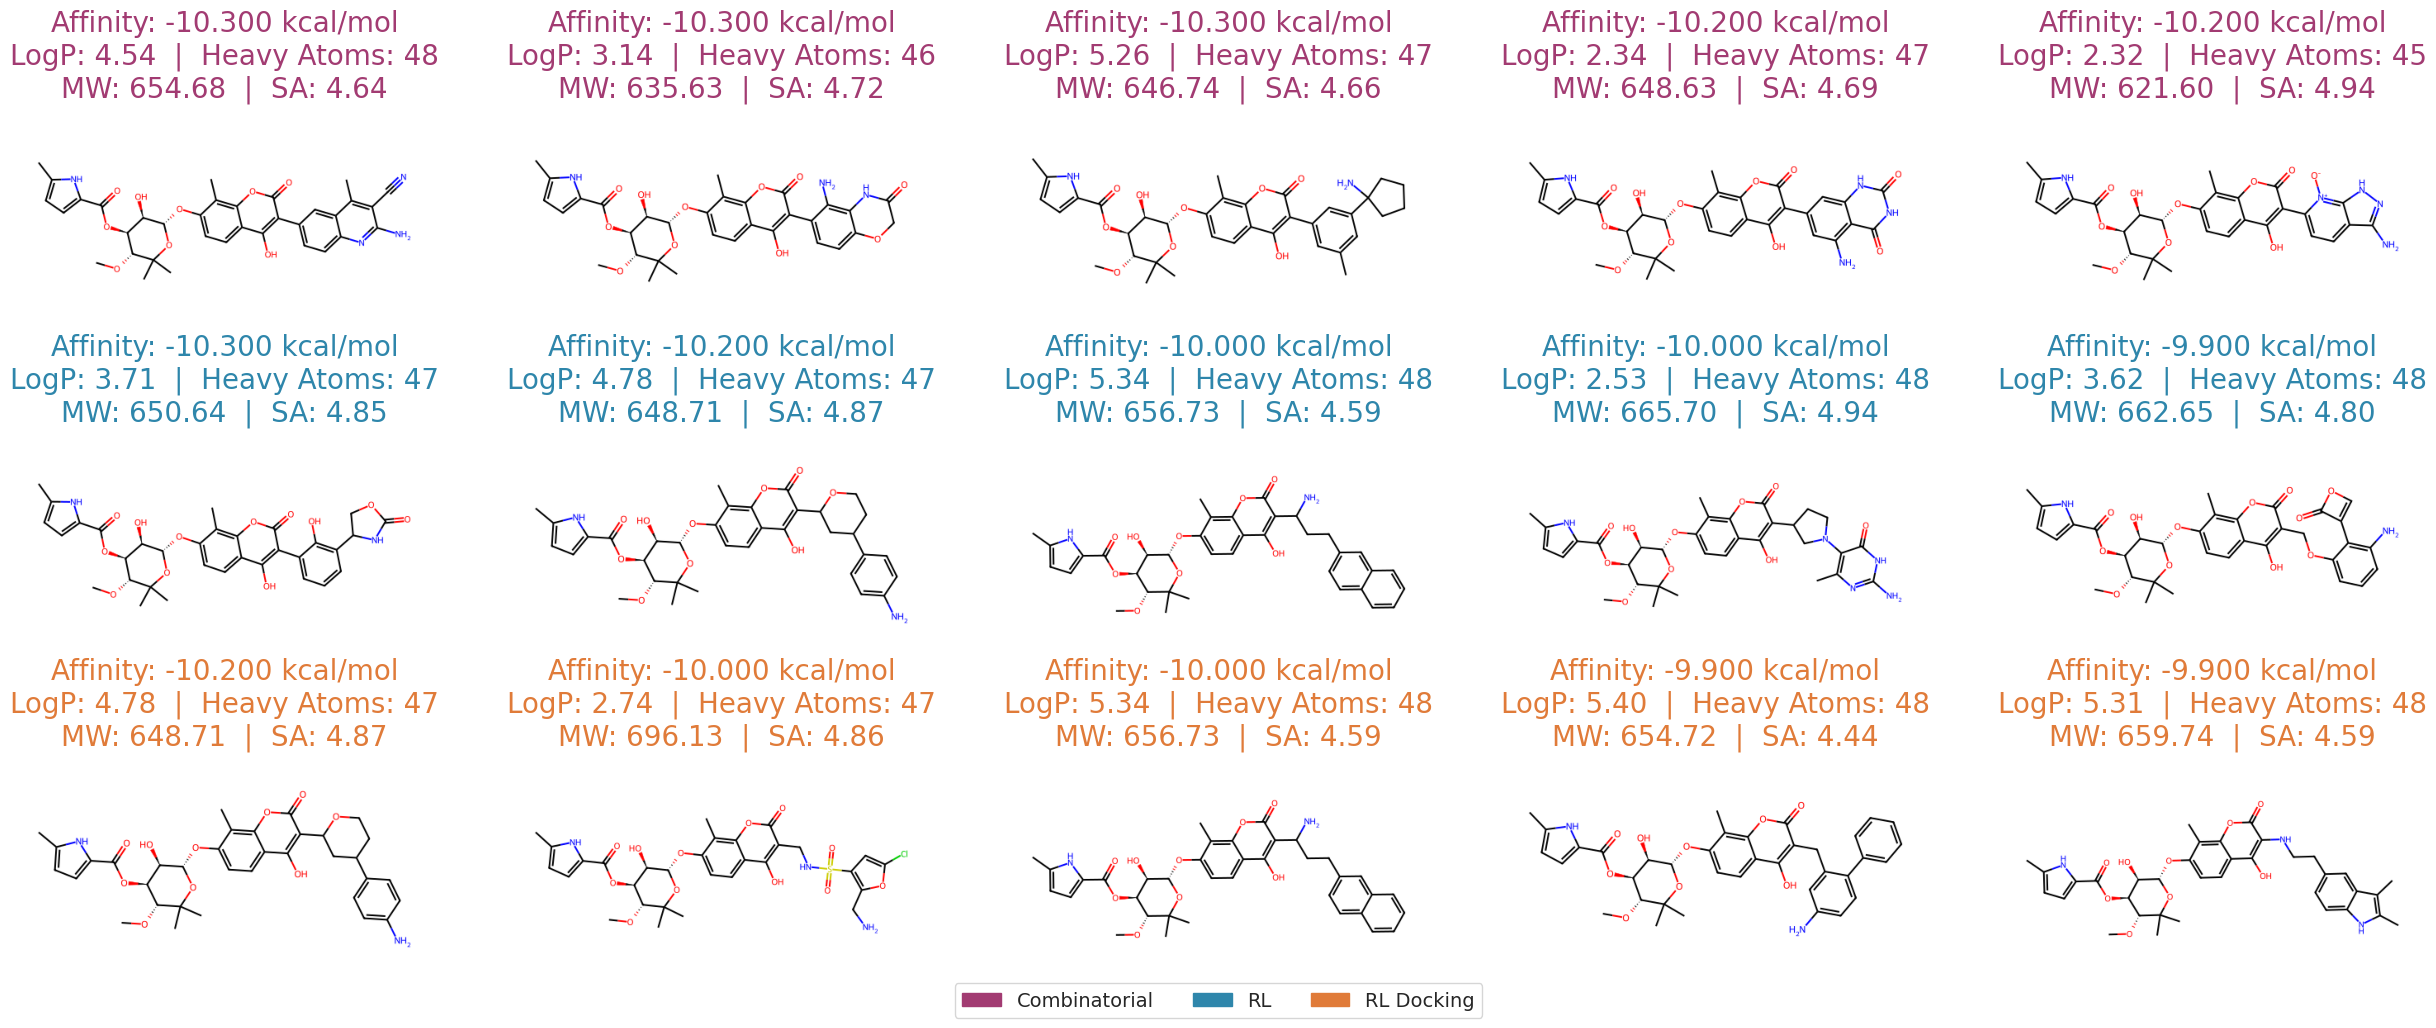

In [7]:
import pandas as pd
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
from rdkit import Chem
from rdkit.Chem import Draw


# ── Tag each dataframe with its source ──────────────────────────────────────
pareto_rl_1stfront_docking         = pareto_rl_1stfront_docking.copy()
pareto_rl_docking_1stfront_docking = pareto_rl_docking_1stfront_docking.copy()
pareto_comb_1stfront_docking       = pareto_comb_1stfront_docking.copy()

pareto_rl_1stfront_docking['source']         = 'RL'
pareto_rl_docking_1stfront_docking['source'] = 'RL Docking'
pareto_comb_1stfront_docking['source']       = 'Combinatorial'

# ── Extract top 5 per dataframe by lowest lowest_mode1_affinity ──────────────
top5_rl         = pareto_rl_1stfront_docking.nsmallest(5, 'lowest_mode1_affinity').reset_index(drop=True)
top5_rl_docking = pareto_rl_docking_1stfront_docking.nsmallest(5, 'lowest_mode1_affinity').reset_index(drop=True)
top5_comb       = pareto_comb_1stfront_docking.nsmallest(5, 'lowest_mode1_affinity').reset_index(drop=True)

# ── Plot: 3 rows × 5 columns ─────────────────────────────────────────────────
fig, axes = plt.subplots(3, 5, figsize=(25, 10))

source_color_map = {
    'RL':      color_rl,
    'RL Docking':     color_rl_docking,
    'Combinatorial':  color_comb,
}

for row_idx, top5 in enumerate([top5_comb, top5_rl, top5_rl_docking]):
    for col_idx, (_, mol_row) in enumerate(top5.iterrows()):
        ax = axes[row_idx, col_idx]
        mol = Chem.MolFromSmiles(mol_row['SMILES'])
        img = Draw.MolToImage(mol, size=(500, 300))
        source = mol_row['source']
        color  = source_color_map[source]

        ax.imshow(img)
        ax.axis('off')

        label = (
            f"Affinity: {mol_row['lowest_mode1_affinity']:.3f} kcal/mol\n"
            f"LogP: {mol_row['LogP']:.2f}  |  Heavy Atoms: {int(mol_row['NumHeavyAtoms'])}\n"
            f"MW: {mol_row['MW']:.2f}  |  SA: {mol_row['SA']:.2f}"
        )
        ax.set_title(label, fontsize=20, color=color, pad=0)

# ── Row labels ────────────────────────────────────────────────────────────────
row_labels = ['Combinatorial', 'RL', 'RL Docking']
for row_idx, label in enumerate(row_labels):
    color = source_color_map[label]
    axes[row_idx, 0].set_ylabel(label, fontsize=14, color=color,
                                 fontweight='bold', labelpad=10)

# ── Legend ────────────────────────────────────────────────────────────────────
legend_handles = [
    mpatches.Patch(color=color_comb,       label='Combinatorial'),
    mpatches.Patch(color=color_rl,         label='RL'),
    mpatches.Patch(color=color_rl_docking, label='RL Docking'),
]
fig.legend(handles=legend_handles, loc='lower center', ncol=3, fontsize=14,
           frameon=True, bbox_to_anchor=(0.5, -0.02))
plt.tight_layout()
plt.savefig(figure_dir + 'top5_pareto_lowest_affinity.pdf', dpi=600, bbox_inches='tight', format='pdf')
plt.show()

In [21]:
pareto_rl_docking_1stfront_docking.head()

,Step,SMILES,HasSubstructure,LogP,NumHeavyAtoms,MW,SA,Similarity,DockingAffinity,DockScore,Score,PenalizedScore,lowest_mode1_affinity,pareto_rank,source
0,9,CO[C@@H]1[C@@H](OC(=O)c2ccc(C)[nH]2)[C@@H](O)[...,True,1.06134,40.0,560.556,5.043138,0.590000,-8.3,0.5375,0.5375,0.5375,-8.3,1,RL Docking
1,13,CO[C@@H]1[C@@H](OC(=O)c2ccc(C)[nH]2)[C@@H](O)[...,True,3.39324,44.0,607.616,4.368360,0.755319,-7.8,0.4750,0.4750,0.4750,-8.0,1,RL Docking
2,14,CO[C@@H]1[C@@H](OC(=O)c2ccc(C)[nH]2)[C@@H](O)[...,True,4.01008,46.0,635.670,4.511792,0.726316,-9.5,0.6875,0.6875,0.6875,-9.5,1,RL Docking
3,14,CO[C@@H]1[C@@H](OC(=O)c2ccc(C)[nH]2)[C@@H](O)[...,True,3.37364,44.0,605.600,4.663339,0.582524,-9.3,0.6625,0.6625,0.6625,-9.3,1,RL Docking
4,17,CO[C@@H]1[C@@H](OC(=O)c2ccc(C)[nH]2)[C@@H](O)[...,True,3.25816,46.0,657.698,4.548061,0.637255,-9.4,0.6750,0.6750,0.6750,-9.4,1,RL Docking


### Figure 8

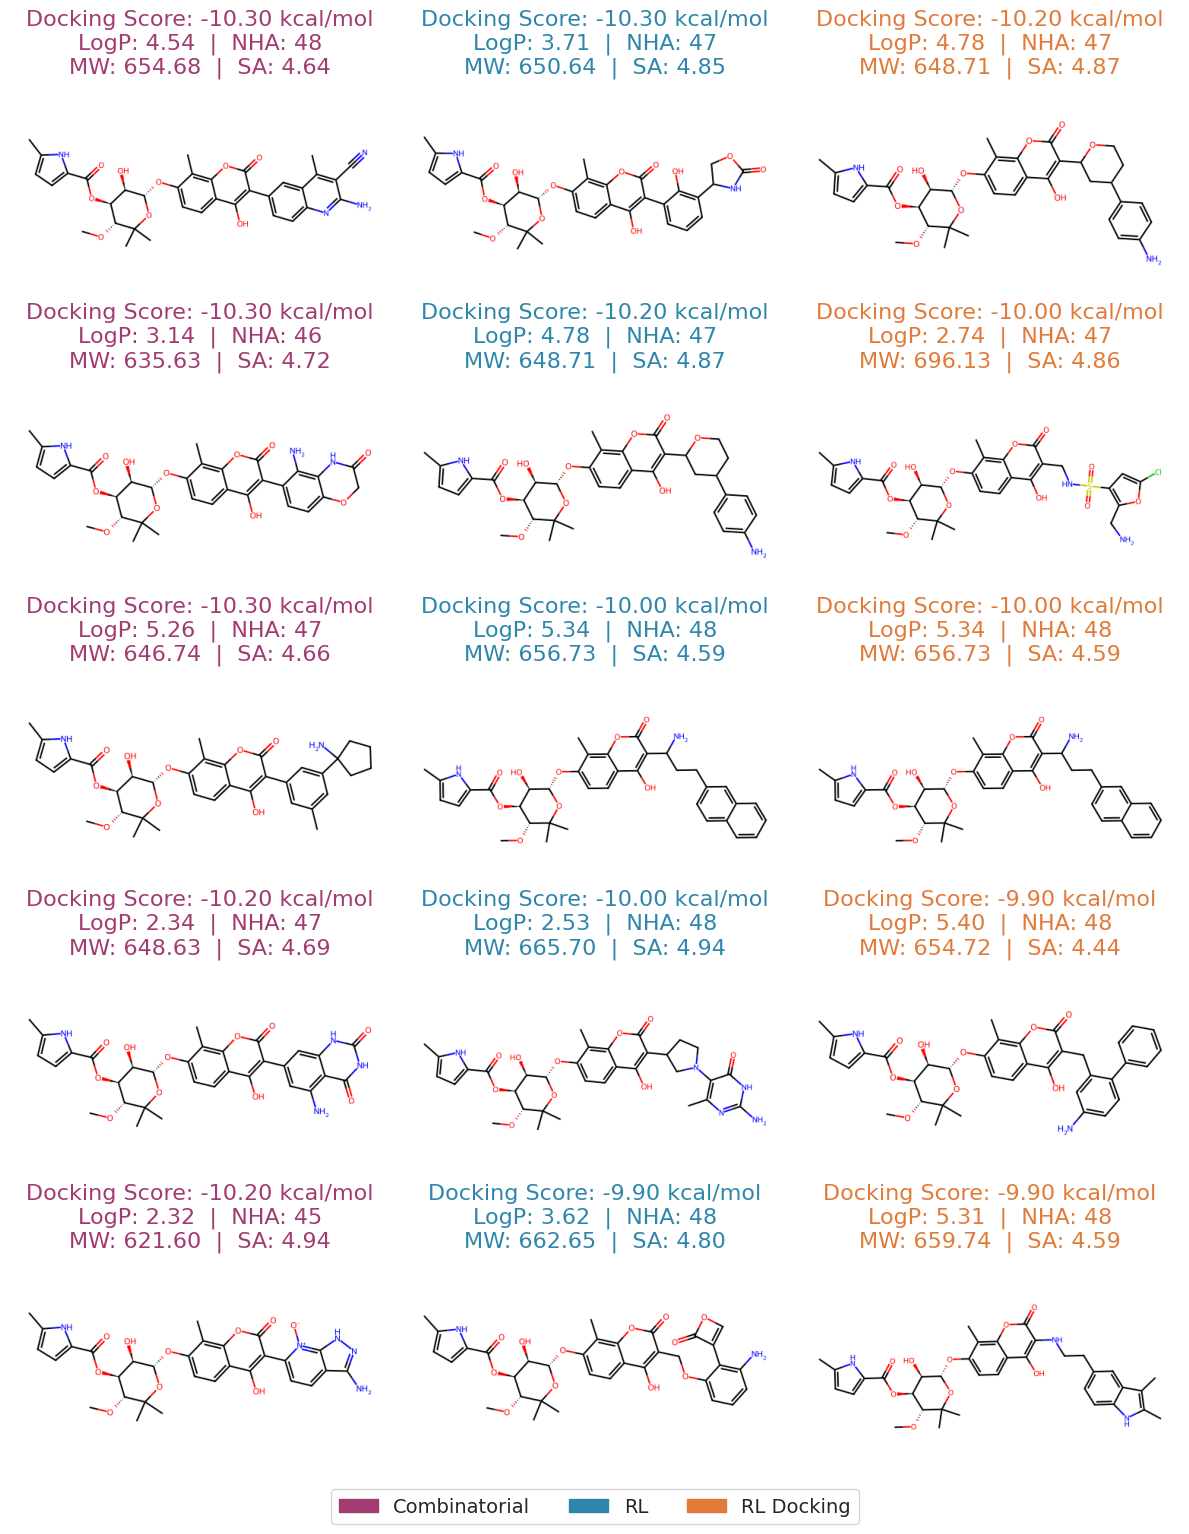

In [28]:
import pandas as pd
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
from rdkit import Chem
from rdkit.Chem import Draw


# ── Tag each dataframe with its source ──────────────────────────────────────
pareto_rl_1stfront_docking         = pareto_rl_1stfront_docking.copy()
pareto_rl_docking_1stfront_docking = pareto_rl_docking_1stfront_docking.copy()
pareto_comb_1stfront_docking       = pareto_comb_1stfront_docking.copy()

pareto_rl_1stfront_docking['source']         = 'RL'
pareto_rl_docking_1stfront_docking['source'] = 'RL Docking'
pareto_comb_1stfront_docking['source']       = 'Combinatorial'

# ── Extract top 5 per dataframe by lowest lowest_mode1_affinity ──────────────
top5_rl         = pareto_rl_1stfront_docking.nsmallest(5, 'lowest_mode1_affinity').reset_index(drop=True)
top5_rl_docking = pareto_rl_docking_1stfront_docking.nsmallest(5, 'lowest_mode1_affinity').reset_index(drop=True)
top5_comb       = pareto_comb_1stfront_docking.nsmallest(5, 'lowest_mode1_affinity').reset_index(drop=True)

# ── Plot: 5 rows × 3 columns ─────────────────────────────────────────────────
fig, axes = plt.subplots(5, 3, figsize=(12, 15))

source_color_map = {
    'RL':            color_rl,
    'RL Docking':    color_rl_docking,
    'Combinatorial': color_comb,
}

for col_idx, top5 in enumerate([top5_comb, top5_rl, top5_rl_docking]):
    for row_idx, (_, mol_row) in enumerate(top5.iterrows()):
        ax = axes[row_idx, col_idx]
        mol = Chem.MolFromSmiles(mol_row['SMILES'])
        img = Draw.MolToImage(mol, size=(500, 300))
        source = mol_row['source']
        color  = source_color_map[source]

        ax.imshow(img)
        ax.axis('off')

        label = (
            f"Docking Score: {mol_row['lowest_mode1_affinity']:.2f} kcal/mol\n"
            f"LogP: {mol_row['LogP']:.2f}  |  NHA: {int(mol_row['NumHeavyAtoms'])}\n"
            f"MW: {mol_row['MW']:.2f}  |  SA: {mol_row['SA']:.2f}"
        )
        ax.set_title(label, fontsize=16, color=color, pad=4)


# ── Legend ────────────────────────────────────────────────────────────────────
legend_handles = [
    mpatches.Patch(color=color_comb,       label='Combinatorial'),
    mpatches.Patch(color=color_rl,         label='RL'),
    mpatches.Patch(color=color_rl_docking, label='RL Docking'),
]
fig.legend(handles=legend_handles, loc='lower center', ncol=3, fontsize=14,
           frameon=True, bbox_to_anchor=(0.5, -0.02))
plt.tight_layout()
plt.savefig(figure_dir + 'figure8_top5_pareto_lowest_affinity.pdf', dpi=300, bbox_inches='tight', format='pdf')
plt.show()